In [2]:
import os
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Đọc dữ liệu
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
# Cấu trúc của bộ dữ liệu
print("Cấu trúc bộ dữ liệu:")
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")

Cấu trúc bộ dữ liệu:
Số dòng: 7043, Số cột: 21


Bộ dữ liệu gồm có 21 thuộc tính và 7043 dòng

In [5]:
# Hiện thông tin của 10 dòng đầu
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Bộ dữ liệu gồm các thuộc tính:
- customerID: Mã định danh khách hàng
- gender: Giới tính (Male/Female)
- SeniorCitizen: Có phải người cao tuổi (1 = có, 0 = không)
- Partner: Có bạn đời hay không (Yes/No)
- Dependents: Có người phụ thuộc không (Yes/No)
- tenure: Số tháng gắn bó với công ty
- PhoneService: Có dịch vụ điện thoại không
- MultipleLines: Có nhiều đường dây điện thoại không
- InternetService: Loại dịch vụ Internet (DSL/Fiberoptic/None)
- OnlineSecurity: Có dịch vụ bảo mật trực tuyến không
- OnlineBackup: Có dịch vụ sao lưu trực tuyến không
- DeviceProtection: Có bảo vệ thiết bị không
- TechSupport: Có hỗ trợ kỹ thuật không
- StreamingTV: Có xem TV trực tuyến không
- StreamingMovies: Có xem phim trực tuyến không
- Contract: Loại hợp đồng (Month-to-month/One year/Two year)
- PaperlessBilling: Có hoá đơn điện tử không (Yes/No)
- PaymentMethod: Phương thức thanh toán
- MonthlyCharges: Chi phí hàng tháng
- TotalCharges: Tổng chi phí
- Churn: Khách hàng có rời bỏ không (Yes/No)

In [6]:
# Xem thông tin tổng quát của các cột
print("Tên cột và kiểu dữ liệu:")
df.info()

Tên cột và kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

Khi nhìn vào kiểu dữ liệu của bộ dữ liệu, đang có hai biến không đúng kiểu dữ liệu là: TotalCharges (đang là object, lẽ ra là float64), SeniorCitizen - Là người cao tuổi (đang là int64, lẽ ra là object)

In [7]:
# Kiểm tra tổng số giá trị thiếu theo cột
print("Số Missing Values theo từng cột:")
df.isna().sum()

Số Missing Values theo từng cột:


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
# Đếm tổng số dòng bị trùng lặp
print("Tổng số dòng dữ liệu bị trùng lặp:")
df.duplicated().sum()

Tổng số dòng dữ liệu bị trùng lặp:


np.int64(0)

Bộ dữ liệu không có giá trị khuyết và không có giá trị trùng lặp

In [9]:
# Xử lí kiểu dữ liệu cho cột Senior Citizen
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

# Đồng bộ Yes / No giống những cột khác
df['SeniorCitizen'] = df['SeniorCitizen'].replace({1: 'Yes', 0: 'No'})

Đổi kiểu dữ liệu của cột Senior Citizen về kiểu object và chỉnh giá trị về Yes và No giống những cột khác

In [10]:
# Chuyển đổi kiểu dữ liệu của cột TotalCharges thành dạng số
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
# Kiểm tra lại tình trạng missing value
print("Số Missing Values theo từng cột:")
df.isna().sum()

Số Missing Values theo từng cột:


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Sau khi đổi kiểu dữ liệu của TotalCharges về đúng dữ liệu số, lúc này bộ dữ liệu xuất hiện 11 giá trị khuyết

In [12]:
# Lọc ra các dòng mà biến TotalCharges đang thiếu
rows_missing = df[df['TotalCharges'].isnull()]

# In ra dữ liệu của 11 dòng bị thiếu
print(rows_missing)

      customerID  gender SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female            No     Yes        Yes       0   
753   3115-CZMZD    Male            No      No        Yes       0   
936   5709-LVOEQ  Female            No     Yes        Yes       0   
1082  4367-NUYAO    Male            No     Yes        Yes       0   
1340  1371-DWPAZ  Female            No     Yes        Yes       0   
3331  7644-OMVMY    Male            No     Yes        Yes       0   
3826  3213-VVOLG    Male            No     Yes        Yes       0   
4380  2520-SGTTA  Female            No     Yes        Yes       0   
5218  2923-ARZLG    Male            No     Yes        Yes       0   
6670  4075-WKNIU  Female            No     Yes        Yes       0   
6754  2775-SEFEE    Male            No      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  ...   
753      

Lúc này, khi nhìn vào cột Tenure (Số tháng gắn bó với công ty) đều bằng 0 và cột TotalCharges đều là NaN, đây đều là những khách hàng mới, chưa hết tháng đầu tiên nên chưa phát sinh tổng hoá đơn (TotalCharges) là hợp lí. Vậy nên, phải suy nghĩ để xử lí missing values:
- Khi đã đăng kí dịch vụ, thường phải thanh toán trước gói cước tháng đầu, khi đó TotalCharges = MonthlyCharges (đây là cách hoạt động của hình thức trả trước)
- Tuy nhiên khi xử lí theo cách đó sẽ tạo ra outlier trong mối quan hệ tuyến tính khi mà: những người khác Total / Monthly = Tenure, còn 11 người này Total/Monthly = 1 (Mà Tenure = 0), sẽ tạo ra mâu thuẫn sẽ làm nhiễu mô hình sau này
- Nên nhóm quyết định, xử lí giá trị khuyết chỗ này bằng cách điền 0 (phù hợp với cách hoạt động của hình thức trả sau)

In [13]:
# Điền khuyết TotalCharges bằng giá trị 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [14]:
# Kiểm tra lại tình trạng missing value và kiểu dữ liệu
print("Tên cột và kiểu dữ liệu:")
df.info()

Tên cột và kiểu dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

Sau khi xử lí, dữ liệu của các cột đều đã đúng và cột TotalCharges đã không còn giá trị khuyết

In [15]:
# Xem thống kê các biến số
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


## Phân tích đơn biến - Univariate Analysis

In [16]:
# Cài đặt chung cho biểu đồ
sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

### Biến mục tiêu - Churn

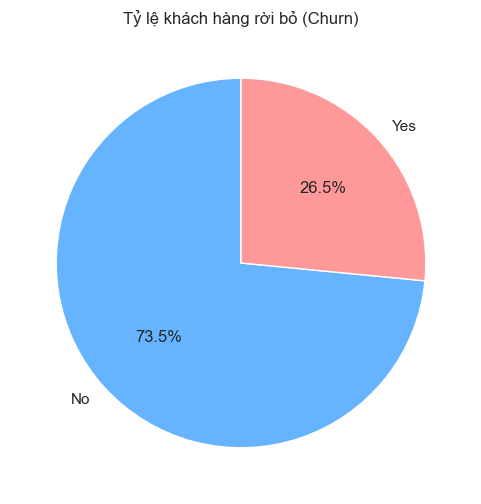

In [17]:
# Xem tỷ lệ khách hàng rời bỏ
plt.figure(figsize=(6, 6))
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Tỷ lệ khách hàng rời bỏ (Churn)')
plt.show()

- Tỉ lệ khách hàng không rời bỏ (No - Màu xanh): Chiếm đa số với 73.5%
- Tỉ lệ khách hàng rời bỏ (Yes - Màu đỏ): Chiếm 26.5%, thường được coi là rất cao trong hầu hết các ngành công nghiệp (như viễn thông, ngân hàng,...). Điều này có nghĩa là cứ 4 khách hàng thì doanh nghiệp đang mất đi hơn 1 người. Để doanh nghiệp tăng trưởng, tốc độ thu hút khách hàng mới phải lớn hơn tốc độ rời bỏ này. Với tỷ lệ 26.5%, chi phí để bù đắp lượng khách hàng đã mất sẽ tạo gánh nặng lớn lên doanh thu. Lúc này đây, doanh nghiệp cần tập trung nguồn lực để tìm hiểu tại sao nhóm 26.5% này lại rời đi

### Phân tích biến định lượng (Numerical)

#### Biểu đồ tần suất (Histogram)

**Biến tenure**

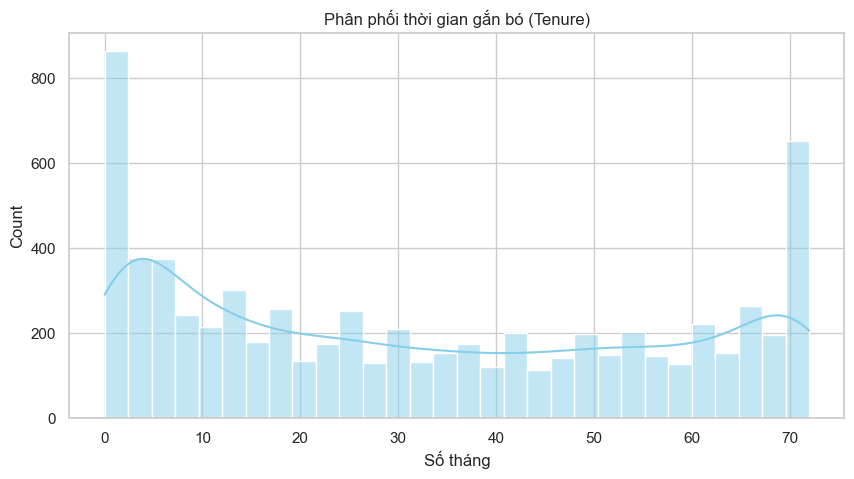

In [18]:
# Biến tenure (Thời gian gắn bó)
# Xem phân phối thời gian gắn bó
plt.figure(figsize=(10, 5))
sns.histplot(df['tenure'], kde=True, bins=30, color='skyblue')
plt.title('Phân phối thời gian gắn bó (Tenure)')
plt.xlabel('Số tháng')
plt.show()

Biểu đồ không tuân theo phân phối chuẩn mà có dạng U-shape (hình chữ U) với hai cực đối lập rõ rệt:
- Bên trái: Tập trung rất lớn lượng khách hàng mới (Tenure thấp, khoảng 0-5 tháng). Cột cao nhất nằm ở ngay vị trí đầu tiên (0-2 tháng), điều này cho thấy doanh nghiệp có khả năng thu hút khách hàng mới tốt, nhưng cũng ám chỉ rằng có một lượng lớn khách hàng có thể rời bỏ ngay sau khi trải nghiệm tháng đầu tiên. Trong bài toán Churn, đây thường là giai đoạn "Rời bỏ sớm". Nếu khách hàng vượt qua được giai đoạn này, họ mới có xu hướng gắn bó lâu dài
- Bên phải: Tập trung lượng lớn khách hàng lâu năm (Tenure cao, khoảng 70-72 tháng). Đây là những khách hàng cực kỳ trung thành, có thể đã gắn bó từ khi dịch vụ mới thành lập. Nhóm này thường mang lại doanh thu ổn định và ít nhạy cảm với thay đổi giá hơn
- Phần giữa: Phân phối khá phẳng và đồng đều. Khách hàng trong giai đoạn này ít biến động hơn so với hai đầu mút

**Biến MonthlyCharges**

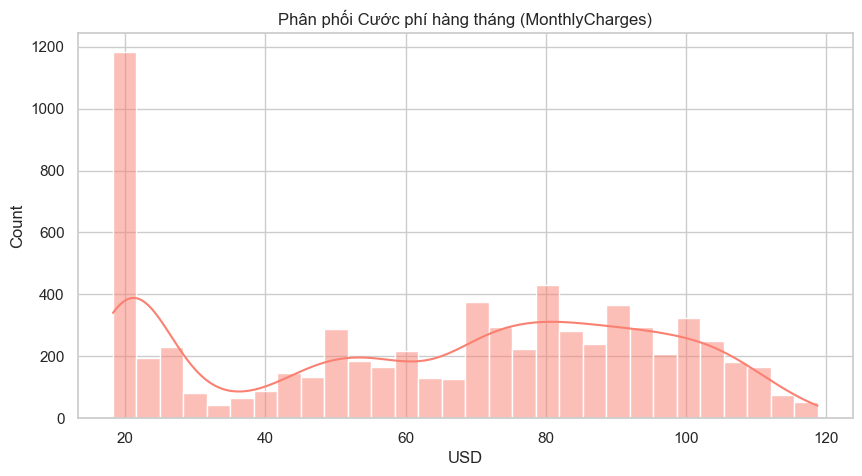

In [19]:
# Biến MonthlyCharges (Cước phí hàng tháng)
# Xem phân phối cước phí tháng
plt.figure(figsize=(10, 5))
sns.histplot(df['MonthlyCharges'], kde=True, bins=30, color='salmon')
plt.title('Phân phối Cước phí hàng tháng (MonthlyCharges)')
plt.xlabel('USD')
plt.show()

Biểu đồ có dạng đa đỉnh:
- Nhóm cước phí thấp (khoảng 20USD): Có một cột dựng đứng rất cao ở ngay đầu biểu đồ cho thấy doanh nghiệp có một gói cước cơ bản rất phổ biến, đông về số lượng nhưng giá trị trên mỗi khách thấp
- Nhóm cước phí cao (khoảng 70 - 100USD): Có một vùng phân phối rộng và cao, tập trung đông đảo khách hàng. Đây có thể là nhóm khách hàng sử dụng các gói Combo dù số lượng từng cột không cao bằng mức 20 USD, nhưng tổng lượng khách hàng trong vùng này rất lớn
- Vùng trũng (khoảng 30 - 60 USD): Số lượng khách hàng ở mức cước trung bình này thấp hơn hẳn, cho thấy doanh nghiệp có thể đang thiếu các gói cước tầm trung hấp dẫn

**Biến TotalCharges**

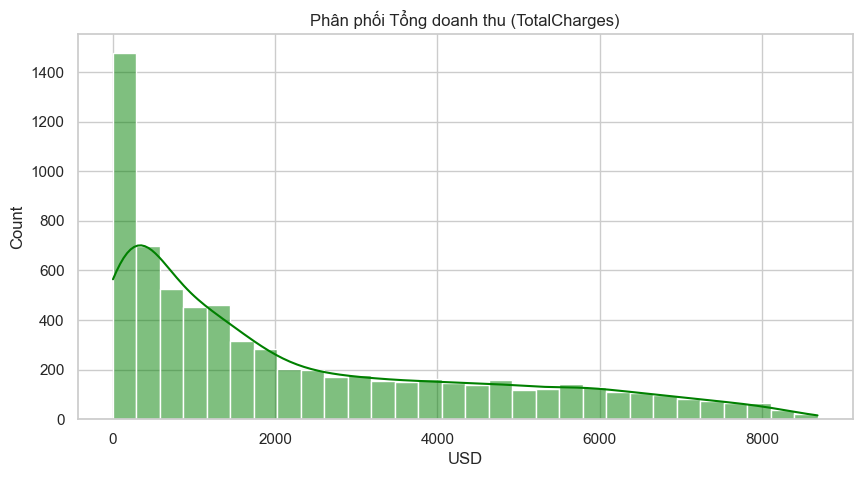

In [20]:
# Biến TotalCharges (Tổng doanh thu)
# Xem phân phối tổng doanh thu
plt.figure(figsize=(10, 5))
sns.histplot(df['TotalCharges'], kde=True, bins=30, color='green')
plt.title('Phân phối Tổng doanh thu (TotalCharges)')
plt.xlabel('USD')
plt.show()

Biểu đồ có dạng phân phối lệch phải:
- Sự phân bố của TotalCharges là hệ quả logic khi kết hợp hai biến trước đó (TotalCharges ≈ Tenure x MonthlyCharges)
- Cột đầu tiên cao vọt vì do lượng khách hàng mới rất đông, cộng thêm nhóm khách hàng sử dụng gói cước rẻ. Hai yếu tố này cộng hưởng tạo ra một lượng lớn khách hàng có tổng chi tiêu (TotalCharges) rất thấp
- Những khách hàng ở phần đuôi (6000 - 8000 USD) là những "khách hàng VIP, vừa có thâm niên cao vừa dùng gói cước đắt. Tuy số lượng ít, nhưng vẫn đóng góp lớn vào doanh thu tổng

#### Biểu đồ hộp (Boxplot)

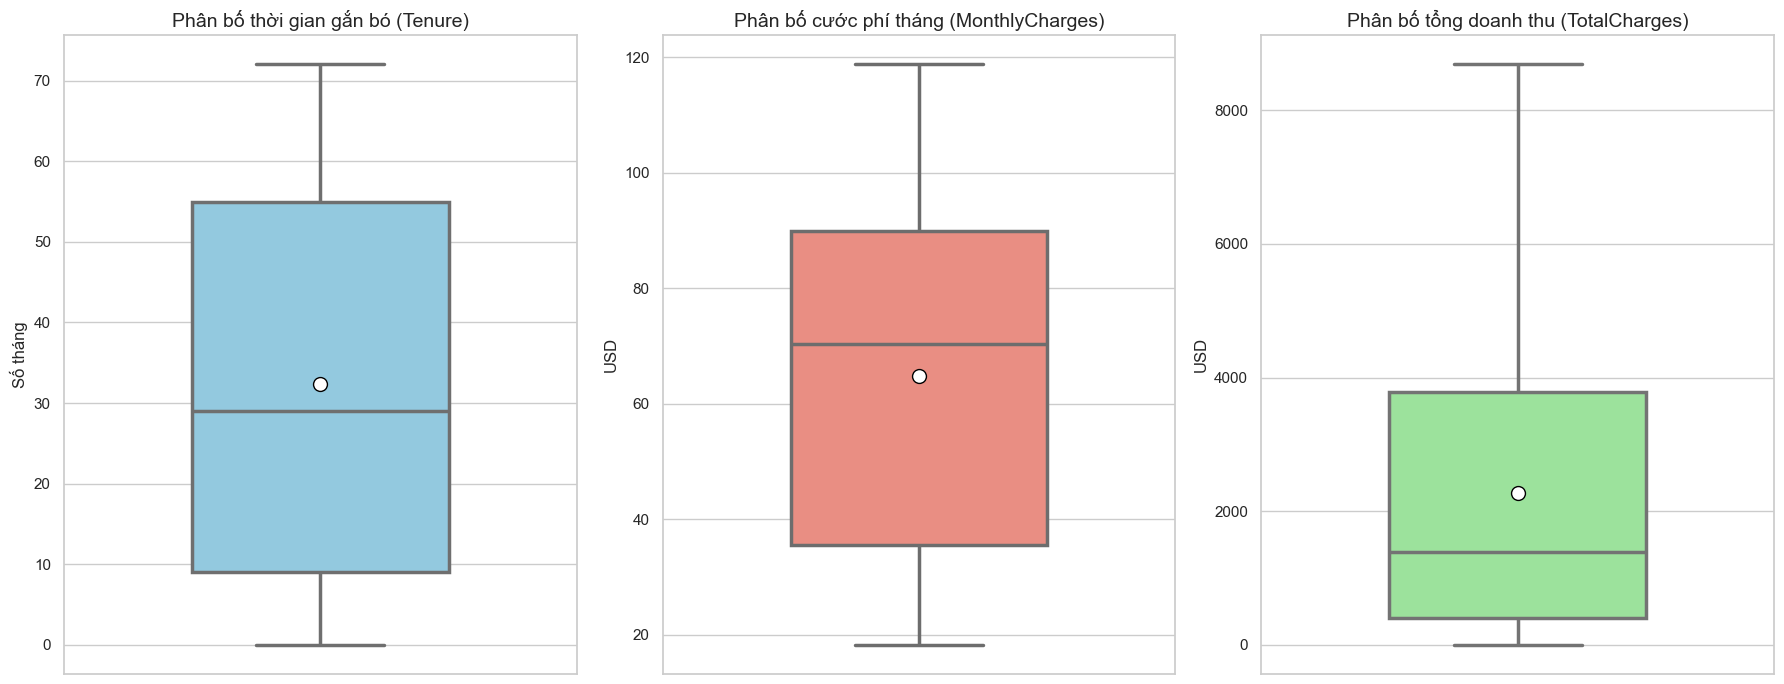

In [21]:
# Vẽ Boxplot để kiểm tra ngoại lai (Outliers)
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Boxplot Tenure
sns.boxplot(y=df['tenure'], ax=axes[0], color='skyblue', width=0.5, linewidth=2.5, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})
axes[0].set_title('Phân bố thời gian gắn bó (Tenure)', fontsize=14)
axes[0].set_ylabel('Số tháng')

# Boxplot MonthlyCharges
sns.boxplot(y=df['MonthlyCharges'], ax=axes[1], color='salmon', width=0.5, linewidth=2.5, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})
axes[1].set_title('Phân bố cước phí tháng (MonthlyCharges)', fontsize=14)
axes[1].set_ylabel('USD')

# Boxplot TotalCharges
sns.boxplot(y=df['TotalCharges'], ax=axes[2], color='lightgreen', width=0.5, linewidth=2.5, showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})
axes[2].set_title('Phân bố tổng doanh thu (TotalCharges)', fontsize=14)
axes[2].set_ylabel('USD')

plt.tight_layout()
plt.show()

Không nhìn thấy có biến ngoại lai nào trong các biểu đồ boxplot trong hình

### Phân tích các biến định tính (Categorical)

**Biến Contract**

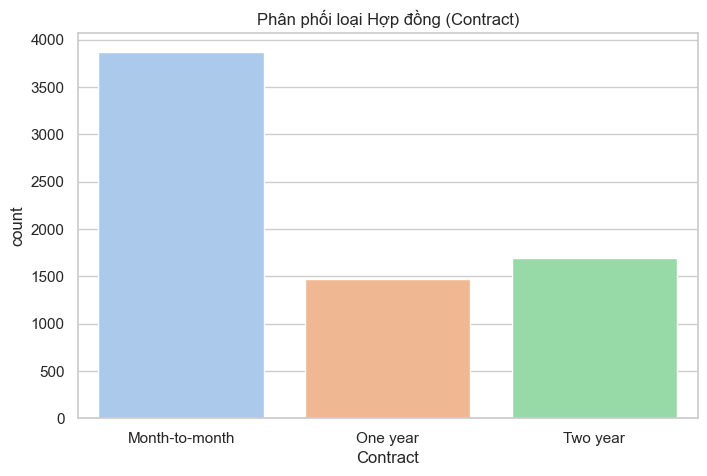

In [22]:
# Biến Contract (Loại hợp đồng)
# Xem loại hợp đồng khách hàng hay ký nhất
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Contract', data=df, palette='pastel')
plt.title('Phân phối loại Hợp đồng (Contract)')
plt.show()

- Cột "Month-to-month" (Thanh toán theo tháng) cao vượt trội, đạt gần 4.000 khách hàng, cho thấy phần lớn khách hàng thích sự linh hoạt. Họ không muốn bị ràng buộc. Tuy nhiên, đây chính là "điểm yếu" của doanh nghiệp vì rào cản rời bỏ của nhóm này gần như bằng 0
- Hai cột "One year" và "Two year" thấp hơn nhưng đại diện cho những khách hàng trung thành

**Biến PaymentMethod**

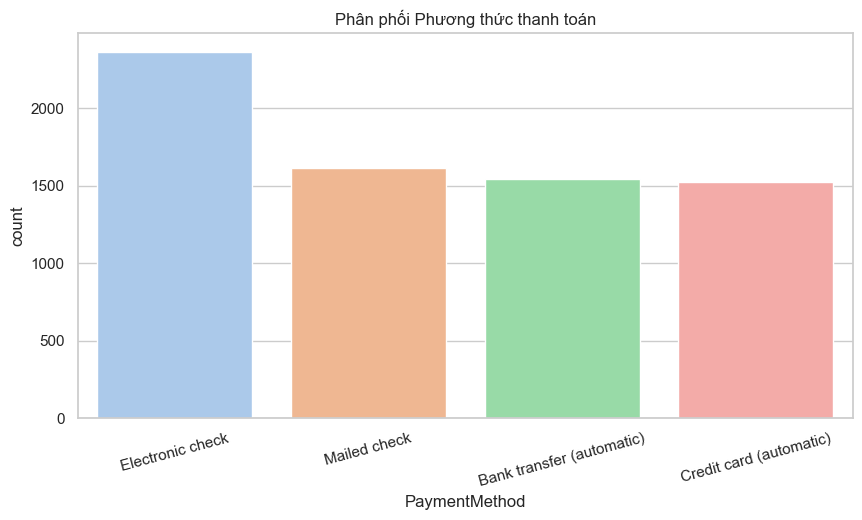

In [23]:
# Biến PaymentMethod (Phương thức thanh toán)
# Xem phương thức thanh toán phổ biến
plt.figure(figsize=(10, 5))
sns.countplot(x='PaymentMethod', data=df, palette='pastel')
plt.title('Phân phối Phương thức thanh toán')
plt.xticks(rotation=15)
plt.show()

- Cột "Electronic check" cao vượt trội so với 3 phương thức còn lại, đạt hơn 2000 khách hàng. Đây là phương thức thanh toán thủ công (khách hàng phải thực hiện thao tác thanh toán mỗi tháng) và thường không yêu cầu cam kết lâu dài
- Hai cột "Bank transfer (automatic)" và "Credit card (automatic)" có chiều cao tương đương nhau và thấp hơn nhiều so với Electronic check
- Rủi ro: "Electronic" check thường là nhóm khách hàng có độ biến động cao nhất. Việc phải chủ động móc hầu bao trả tiền mỗi tháng khiến họ liên tục cân nhắc lại quyết định: "Liệu dịch vụ này có đáng tiền không?"

**Biến PaperlessBilling**

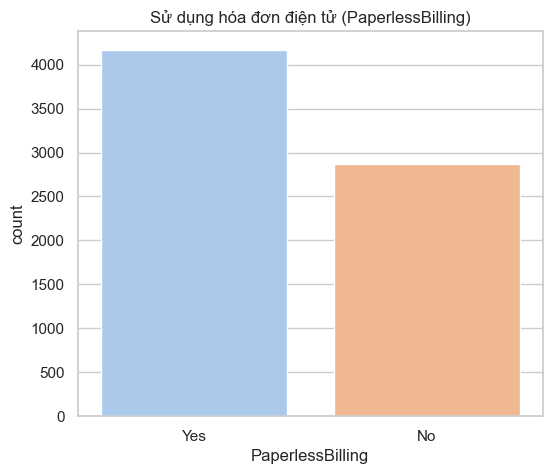

In [24]:
# Biến PaperlessBilling (Hóa đơn điện tử)
# Xem phân phối hoá đơn điện tử
plt.figure(figsize=(6, 5))
sns.countplot(x='PaperlessBilling', data=df, palette='pastel')
plt.title('Sử dụng hóa đơn điện tử (PaperlessBilling)')
plt.show()

- Cột "Yes" (Có dùng hóa đơn điện tử) cao hơn hẳn cột "No", với khoảng 4.100 khách hàng so với 2.800 khách hàng. Khách hàng của doanh nghiệp quen với việc nhận thông báo qua email hoặc ứng dụng thay vì thư tay truyền thống

**Biến gender**

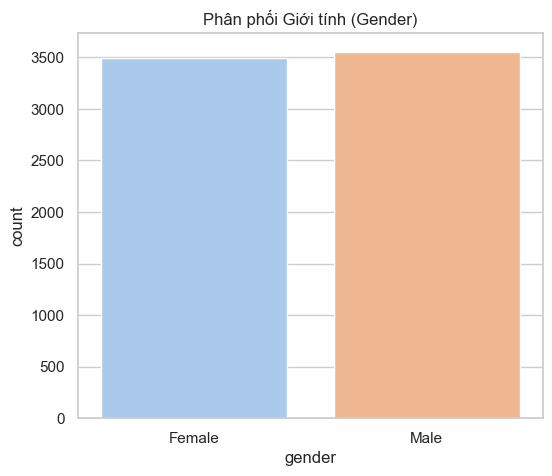

In [25]:
# Biến gender (Giới tính)
# Xem phân phối giới tính của khách hàng
plt.figure(figsize=(6, 5))
sns.countplot(x='gender', data=df, palette='pastel')
plt.title('Phân phối Giới tính (Gender)')
plt.show()

- Phân phối giới tính khách hàng của doanh nghiệp khá đồng đều, khách hàng nam (Male - 50.5%) chỉ hơn khách hàng nữ (Female - 49.5%) một ít

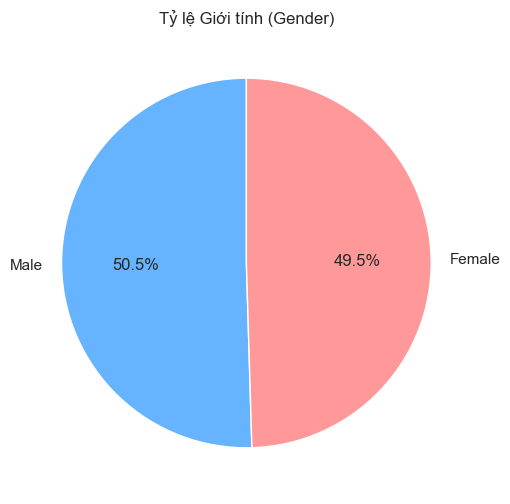

In [26]:
# Xem tỷ lệ Nam/Nữ - Gender
plt.figure(figsize=(6, 6))
counts = df['gender'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Tỷ lệ Giới tính (Gender)')
plt.show()

**Biến SeniorCitizen**

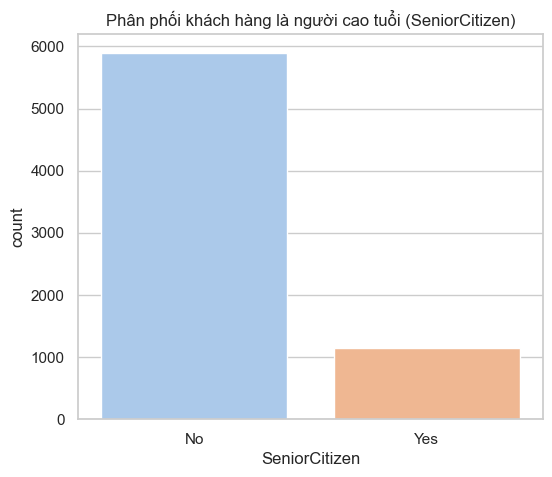

In [27]:
# Biến SeniorCitizen (Người cao tuổi)
# Xem tỉ lệ người cao tuổi
plt.figure(figsize=(6, 5))
sns.countplot(x='SeniorCitizen', data=df, palette='pastel')
plt.title('Phân phối khách hàng là người cao tuổi (SeniorCitizen)')
plt.show()

- Cột "No" (Không phải người cao tuổi) chiếm áp đảo tuyệt đối, với gần 6.000 khách hàng
- Trong khi đó, cột "Yes" (Người cao tuổi) chỉ có khoảng 1.100 người
- Điều này cho thấy tệp khách hàng chính của công ty viễn thông này là người trẻ và người trong độ tuổi lao động

**Biến Partner**

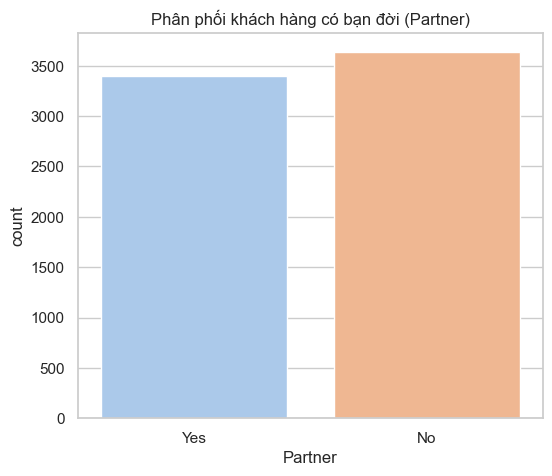

In [28]:
# Biến Partner (Bạn đời)
# Xem tỉ lệ khách hàng có bạn đời
plt.figure(figsize=(6, 5))
sns.countplot(x='Partner', data=df, palette='pastel')
plt.title('Phân phối khách hàng có bạn đời (Partner)')
plt.show()

- Hai cột "Yes" (Có bạn đời) và "No" (Độc thân) có chiều cao gần như tương đương nhau, chênh lệch nhỏ
- Nhóm "Yes" (Có bạn đời): đại diện cho các hộ gia đình hoặc cặp đôi. Nhóm này thường có xu hướng ít thay đổi chỗ ở hơn, tài chính ổn định hơn và có nhu cầu sử dụng dịch vụ cho cả gia đình
- Nhóm "No" (Độc thân): Có thể là sinh viên, người mới đi làm hoặc người sống một mình, nhóm này linh hoạt hơn, dễ thay đổi chỗ ở, nhạy cảm về giá hơn

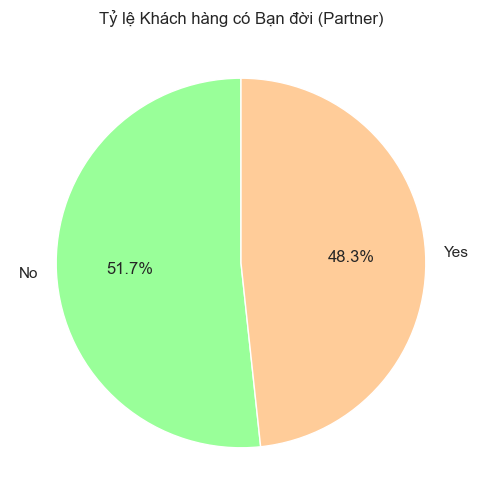

In [29]:
# Xem tỷ lệ có bạn đời - Partner
plt.figure(figsize=(6, 6))
counts = df['Partner'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['#99ff99','#ffcc99'])
plt.title('Tỷ lệ Khách hàng có Bạn đời (Partner)')
plt.show()

**Biến Dependents**

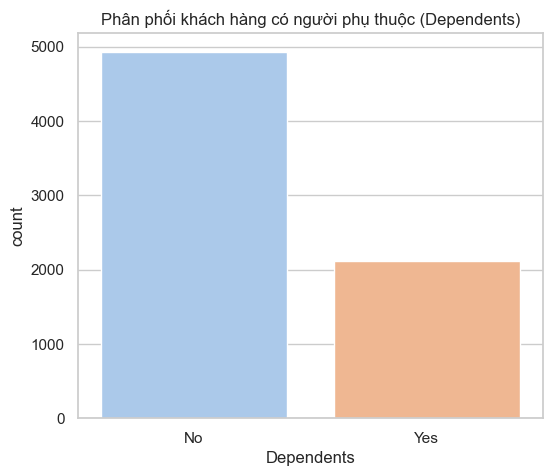

In [30]:
# Biến Dependents (Người phụ thuộc)
# Xem tỉ lệ khách hàng có người phụ thuộc
plt.figure(figsize=(6, 5))
sns.countplot(x='Dependents', data=df, palette='pastel')
plt.title('Phân phối khách hàng có người phụ thuộc (Dependents)')
plt.show()

- Nhóm "No" (Không có người phụ thuộc) chiếm đa số, với gần 5.000 khách hàng (70%). Bao gồm người độc thân hoặc cặp đôi trẻ, linh hoạt hơn, gánh nặng tài chính ít hơn, nên họ dễ dàng đưa ra quyết định cắt hợp đồng nếu thấy không hài lòng
- Nhóm "Yes" (Có người phụ thuộc) chỉ chiếm khoảng 2.000 khách hàng (30%). Đây thường là đại diện cho các hộ gia đình lớn. Việc thay đổi nhà mạng ảnh hưởng đến nhiều người, gây gián đoạn sinh hoạt. Do đó, nhóm này thường có xu hướng ngại thay đổi

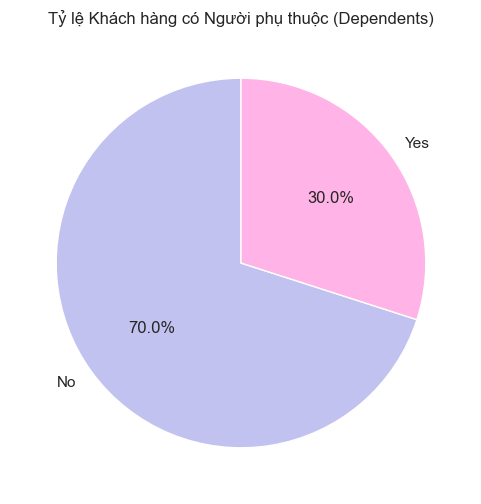

In [31]:
# Xem tỷ lệ có người phụ thuộc (con cái, cha mẹ già...) - Dependents
plt.figure(figsize=(6, 6))
counts = df['Dependents'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['#c2c2f0','#ffb3e6'])
plt.title('Tỷ lệ Khách hàng có Người phụ thuộc (Dependents)')
plt.show()

**Biến InternetService**

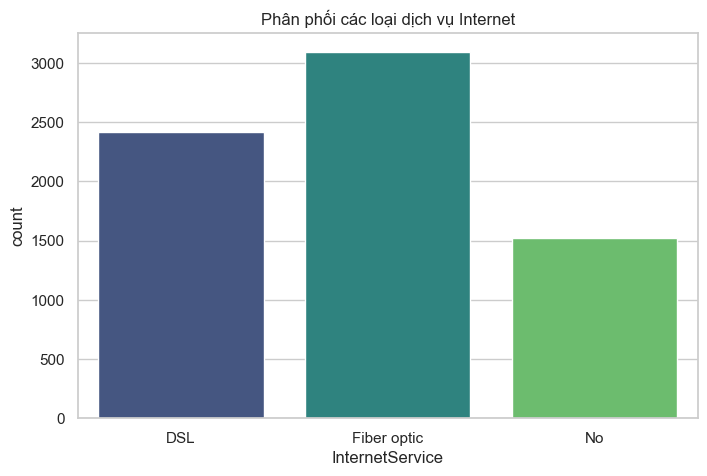

In [32]:
# Biến InternetService (Dịch vụ Internet)
# Phân tích các Dịch vụ
plt.figure(figsize=(8, 5))
sns.countplot(x='InternetService', data=df, palette='viridis')
plt.title('Phân phối các loại dịch vụ Internet')
plt.show()

- Cột "Fiber optic" là cột cao nhất, với hơn 3.000 khách hàng. Đây là công nghệ hiện đại hơn, tốc độ cao hơn và đương nhiên là đắt tiền hơn
- Cột "DS"L chiếm khoảng 2.400 khách hàng. Đây thường là công nghệ cũ hơn, giá rẻ hơn
- Cột "No" (Không dùng Internet) chiếm khoảng 1.500 khách hàng, chỉ sử dụng dịch vụ điện thoại mà không dùng data

**Biến PhoneService**

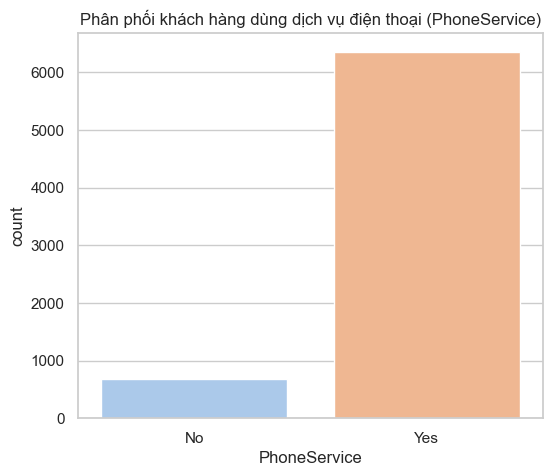

In [33]:
# Biến PhoneService (Dịch vụ điện thoại)
# Xem tỉ lệ người dùng dịch vụ điện thoại
plt.figure(figsize=(6, 5))
sns.countplot(x='PhoneService', data=df, palette='pastel')
plt.title('Phân phối khách hàng dùng dịch vụ điện thoại (PhoneService)')
plt.show()

- Cột "Yes" (Có sử dụng điện thoại) chiếm tỷ lệ áp đảo tuyệt đối, lên tới hơn 6000 khách hàng
- Trong khi đó, cột "No" (Không dùng điện thoại) chỉ vỏn vẹn khoảng 600-700 người. Nhóm này có thể là những người dùng trẻ, chỉ quan tâm đến kết nối dữ liệu cho máy tính bảng hoặc thiết bị thông minh và sử dụng di động cá nhân thay vì điện thoại bàn
- Điều này cho thấy dịch vụ điện thoại là dịch vụ cơ bản của nhà mạng này. Hầu hết khách hàng đến với công ty đều mặc định có dịch vụ này, hoặc nó được tặng kèm trong các gói combo

**Biến MultipleLines**

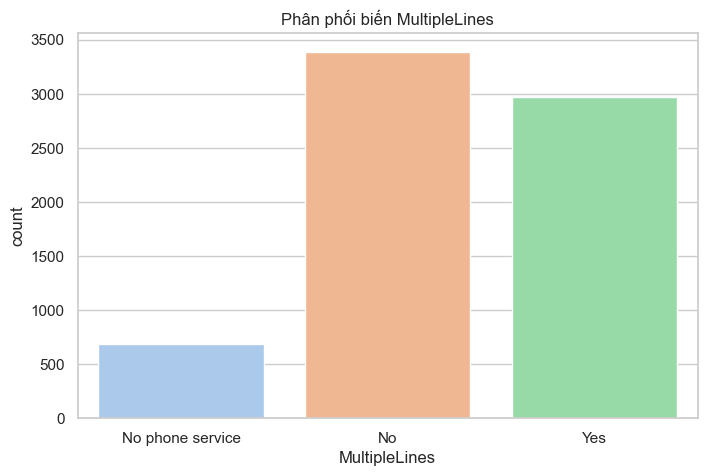

In [34]:
# Biến MultipleLines
# Có nhiều đường dây điện thoại không
plt.figure(figsize=(8, 5))
sns.countplot(x='MultipleLines', data=df, palette='pastel')
plt.title('Phân phối biến MultipleLines')
plt.show()

- Cột "No phone service" (Màu xanh dương): Chiếm khoảng 600 người. Đây chính là nhóm No PhoneService ở biểu đồ trước
- Cột "No" (Màu nâu): Khoảng 3.400 khách hàng. Đây là những người dùng điện thoại nhưng chỉ có 1 đường dây
- Cột "Yes" (Màu xanh lục): Khoảng 3.000 khách hàng. Đây là những người dùng nhiều đường dây
- Tỷ lệ giữa người dùng 1 đường dây và nhiều đường dây là khá cân bằng

**Biến OnlineSecurity**

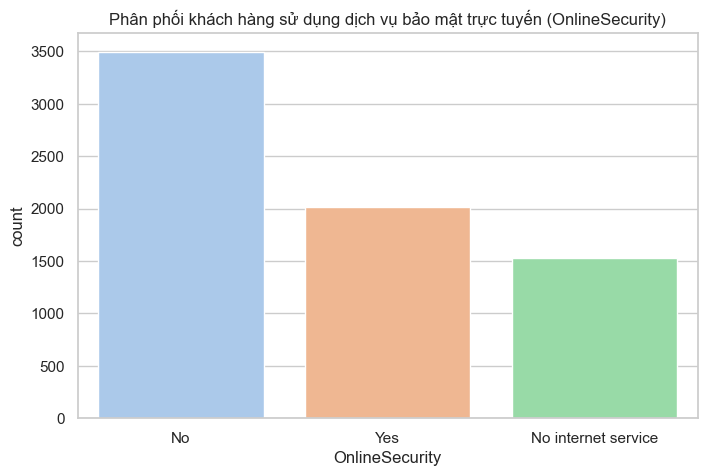

In [35]:
# Dịch vụ bảo mật trực tuyến (OnlineSecurity)
# Xem phân phối khách hàng sử dụng dịch vụ bảo mật trực tuyến
plt.figure(figsize=(8, 5))
sns.countplot(x='OnlineSecurity', data=df, palette='pastel')
plt.title('Phân phối khách hàng sử dụng dịch vụ bảo mật trực tuyến (OnlineSecurity)')
plt.show()

- Cột "No" (Có dùng Internet nhưng không mua bảo mật) cao áp đảo, đạt mức 3.500 khách hàng
- Cột "Yes" (Mua dịch vụ bảo mật) chỉ khoảng 2.000 người
- Cột "No internet service" khớp hoàn toàn với cột No trong biểu đồ InternetService đã vẽ trước đó
- Khách hàng thường không thấy tầm quan trọng của gói bảo mật đi kèm, hoặc họ thấy nó không cần thiết

**Biến TechSecurity**

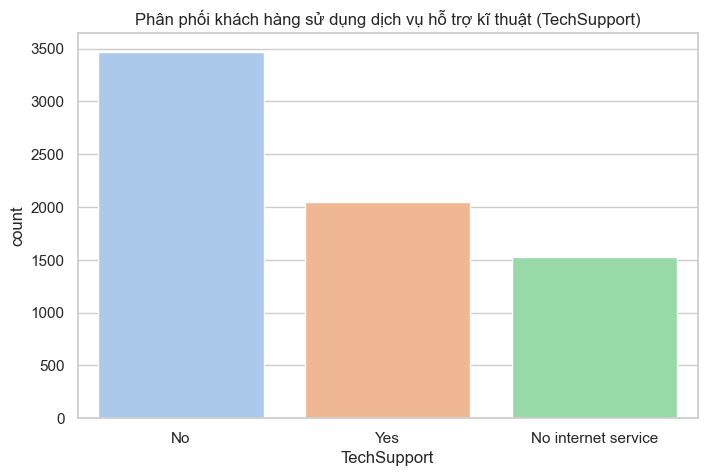

In [36]:
# Hỗ trợ kĩ thuật (TechSecurity)
# Xem phân phối khách hàng sử dụng dịch vụ hỗ trợ kĩ thuật
plt.figure(figsize=(8, 5))
sns.countplot(x='TechSupport', data=df, palette='pastel')
plt.title('Phân phối khách hàng sử dụng dịch vụ hỗ trợ kĩ thuật (TechSupport)')
plt.show()

- Cột "No" (Không dùng hỗ trợ kỹ thuật) cao nhất, với khoảng 3.500 khách hàng.
- Cột "Yes" (dùng hỗ trợ kỹ thuật) với khoảng 2000 khách hàng
- Đa số khách hàng đang sử dụng dịch vụ mà không có hỗ trợ kỹ thuật. ("No" gấp gần 1.75 lần "Yes")

**Biến StreamingTV**

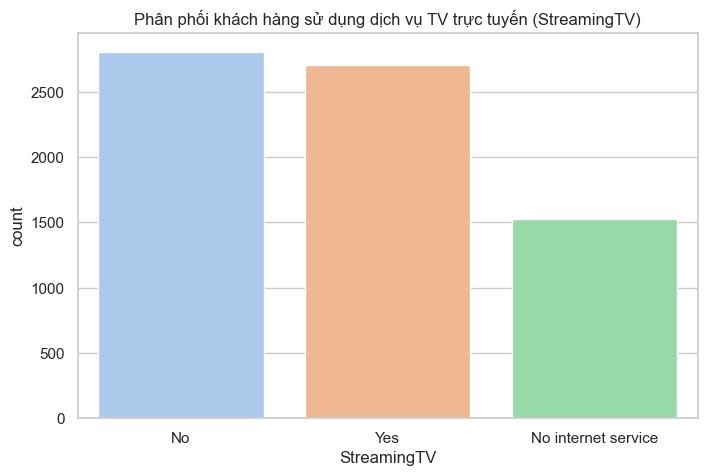

In [37]:
# Dịch vụ TV trực tuyến (StreamingTV)
# Xem phân phối khách hàng sử dụng dịch vụ TV trực tuyến
plt.figure(figsize=(8, 5))
sns.countplot(x='StreamingTV', data=df, palette='pastel')
plt.title('Phân phối khách hàng sử dụng dịch vụ TV trực tuyến (StreamingTV)')
plt.show()

- Bỏ qua nhóm "No internet service" (màu xanh lá), thì tỷ lệ giữa nhóm "No" (màu xanh dương) và "Yes" (màu nâu) là tương đương nhau, đều khoảng 2700-2800 khách hàng
- Điều này cho thấy nhu cầu giải trí là rất lớn và là một động lực quan trọng để khách hàng chi tiền hơn so với dịch vụ hỗ trợ kĩ thuật (TechSupport) ở trên

**Biến StreamingMovies**

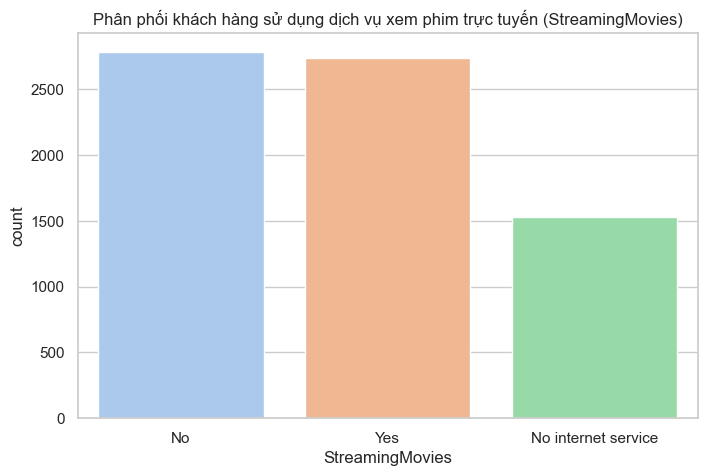

In [38]:
# Dịch vụ xem phim trực tuyến (StreamingMovies)
# Xem phân phối khách hàng sử dụng dịch vụ xem phim trực tuyến
plt.figure(figsize=(8, 5))
sns.countplot(x='StreamingMovies', data=df, palette='pastel')
plt.title('Phân phối khách hàng sử dụng dịch vụ xem phim trực tuyến (StreamingMovies)')
plt.show()

Tương đồng với biến StreamingTV trước đó:
- Cột "No internet service": khoảng 1500 (Giống với những biểu đồ trước)
- Cột "Yes" và "No": Tương đương nhau (khoảng 2.700 - 2.800 khách hàng)
- Điều này khẳng định một hành vi tiêu dùng rõ ràng: Khách hàng đã thích giải trí số thì thường sẽ dùng cả hai (vừa xem TV, vừa xem phim), hoặc không dùng cái nào cả. Rất ít khi họ chỉ chọn một trong hai

**Biến Device Protection**

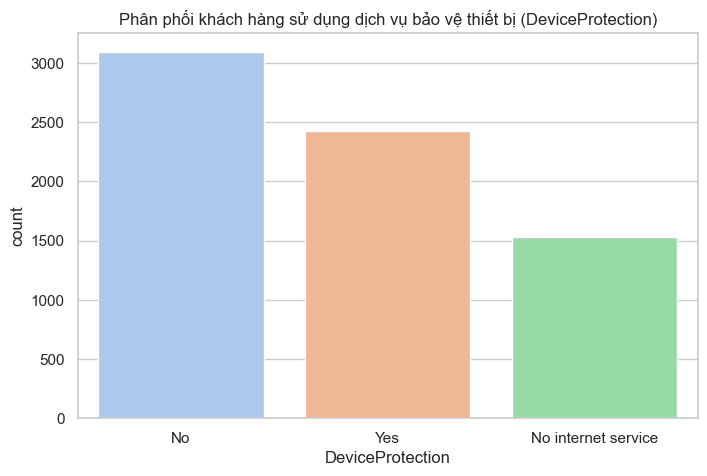

In [39]:
# Dịch vụ bảo vệ thiết bị (DeviceProtection)
# Xem phân phối khách hàng sử dụng dịch vụ bảo vệ thiết bị
plt.figure(figsize=(8, 5))
sns.countplot(x='DeviceProtection', data=df, palette='pastel')
plt.title('Phân phối khách hàng sử dụng dịch vụ bảo vệ thiết bị (DeviceProtection)')
plt.show()

- Nhóm "No" (màu xanh dương): Cao nhất, khoảng 3100 khách hàng
- Nhóm "Yes" (màu nâu): Khoảng 2400 khách hàng
- Nhóm "No internet service": Vẫn cố định ở mức 1500
- Số lượng người mua bảo vệ thiết bị (Yes) cao hơn số người mua hỗ trợ kỹ thuật (TechSupport khoảng 2000) mà ta đã xem trước đó. Cho thấy khách hàng có xu hướng quan tâm đến phần cứng nhiều hơn là phần mềm

**Biến OnlineBackup**

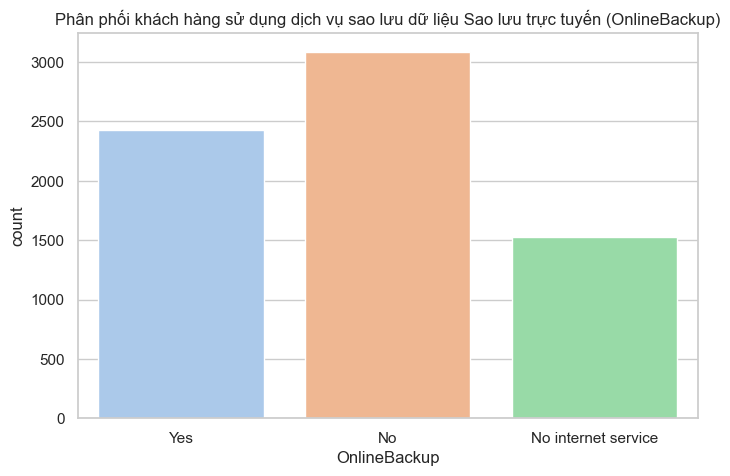

In [40]:
# Dịch vụ sao lưu dữ liệu (OnlineBackup)
# Xem phân phối khách hàng sử dụng dịch vụ sao lưu dữ liệu
plt.figure(figsize=(8, 5))
sns.countplot(x='OnlineBackup', data=df, palette='pastel')
plt.title('Phân phối khách hàng sử dụng dịch vụ sao lưu dữ liệu Sao lưu trực tuyến (OnlineBackup)')
plt.show()

Tương tự với biến DeviceProtection:
- Cột "No" (Không dùng): Cao nhất, khoảng 3100 khách hàng
- Cột "Yes" (Có dùng): Khoảng 2400 khách hàng
- Cột "No internet service": Vẫn cố định ở mức 1500
- Tỷ lệ khách hàng quan tâm đến việc bảo vệ dữ liệu mềm (Backup) cũng tương đương với việc bảo vệ phần cứng (DeviceProtection)

## Phân tích đa biến - Bivariate Analysis

**Mục tiêu của phân tích đâ biến để trả lời câu hỏi: "Yếu tố nào tác động mạnh nhất đến việc khách hàng rời bỏ (Churn)?"**

### Nhóm biến định lượng (Numerical)

**Biến Tenure với Churn**

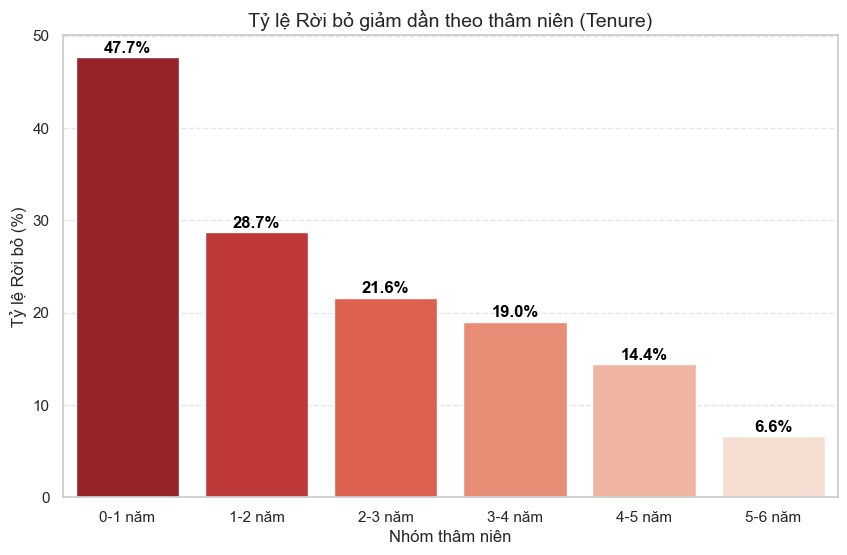

In [41]:
# Biến Tenure vs Churn
# Tạo bản sao tạm thời để xử lý dữ liệu vẽ
df_viz = df.copy()

# Xử lý phân nhóm
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-1 năm', '1-2 năm', '2-3 năm', '3-4 năm', '4-5 năm', '5-6 năm']

df_viz['TenureGroup'] = pd.cut(df_viz['tenure'], bins=bins, labels=labels)

# Tính toán tỷ lệ Churn
churn_by_tenure = df_viz.groupby('TenureGroup', observed=False)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='TenureGroup', y='Churn', data=churn_by_tenure, palette='Reds_r') # Reds_r để màu nhạt dần

plt.title('Tỷ lệ Rời bỏ giảm dần theo thâm niên (Tenure)', fontsize=14)
plt.ylabel('Tỷ lệ Rời bỏ (%)', fontsize=12)
plt.xlabel('Nhóm thâm niên', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm số % lên đầu cột
for index, row in churn_by_tenure.iterrows():
    if not pd.isna(row.Churn):
        plt.text(index, row.Churn + 0.5, f"{row.Churn:.1f}%", color='black', ha="center", fontweight='bold')

plt.show()

Tỷ lệ rời bỏ giảm từ mức 47.7% (năm đầu) xuống chỉ còn 6.6% (năm thứ 6) - Thời gian là liều thuốc thử tốt nhất cho lòng trung thành:
- Từ 0-1 năm: Gần 1 nửa (47.7%) số khách hàng mới rời bỏ ngay trong năm đầu tiên. Đây là giai đoạn sống còn, doanh nghiệp cần dồn ngân sách giữ chân nhóm khách hàng này
- Từ 2-5 năm: tỷ lệ rời bỏ giảm dần nhưng chậm lại (từ 28% xuống 14%). Đây là giai đoạn khách hàng đã quen với dịch vụ. Rủi ro rời bỏ lúc này thường đến từ hết hạn khuyến mãi ban đầu dẫn đến giá cước tăng đột ngột hoặc là đối thủ cạnh tranh tung ra gói cước hấp dẫn hơn
- Từ 5-6 năm: Tỷ lệ rời bỏ chỉ còn 6.6%. Đây chính là nhóm khách hàng mang lại giá trị cao

**Biến MonthlyCharges với Churn**

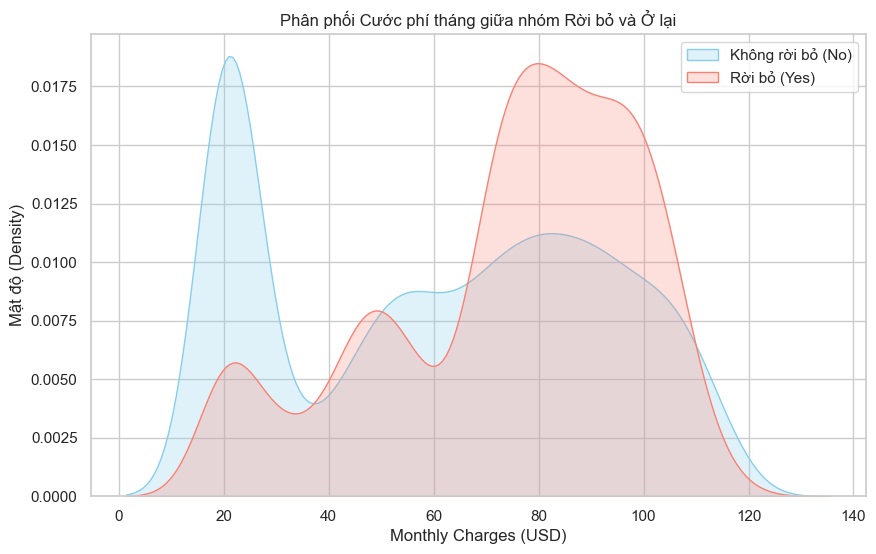

In [42]:
# Biến MonthlyCharges vs Churn
plt.figure(figsize=(10, 6))
# Vẽ biểu đồ mật độ cho nhóm Không rời bỏ (No)
sns.kdeplot(df[df['Churn'] == 'No']['MonthlyCharges'], color='skyblue', fill=True, label='Không rời bỏ (No)')
# Vẽ biểu đồ mật độ cho nhóm Rời bỏ (Yes)
sns.kdeplot(df[df['Churn'] == 'Yes']['MonthlyCharges'], color='salmon', fill=True, label='Rời bỏ (Yes)')

plt.title('Phân phối Cước phí tháng giữa nhóm Rời bỏ và Ở lại')
plt.xlabel('Monthly Charges (USD)')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.show()

- Phân khúc giá rẻ (20 USD): Đường màu xanh (Không rời bỏ) có một đỉnh nhọn cực cao ở mốc 20 USD. Trong khi đó, đường màu đỏ ở khu vực này rất thấp. Những khách hàng sử dụng gói cước cơ bản có độ trung thành cực cao. Với mức giá rẻ như vậy, họ không có nhiều động lực để tìm kiếm nhà cung cấp khác (chi phí chuyển đổi không đáng). Đây là nền tảng khách hàng ổn định của công ty
- Phân khúc cao cấp (70 - 100 USD): Đường màu đỏ (Rời bỏ) phình to và đạt đỉnh ở khoảng giá 80 - 100 USD. Mật độ rời bỏ ở vùng này cao vượt trội so với các vùng giá khác. Khách hàng trả càng nhiều tiền, tỷ lệ rời bỏ càng cao. Họ trả nhiều tiền, kỳ vọng cao, và nếu chất lượng mạng không tốt, họ sẽ rời bỏ ngay lập tức
- Hai đường đồ thị cắt nhau ở khoảng mức giá 60 USD. Dưới 60 là xác suất ở lại cao hơn xác suất rời bỏ. Trên 60 là rủi ro bắt đầu tăng vọt. Mọi khách hàng có hóa đơn 70 USD đều cần được đưa vào danh sách "Chăm sóc đặc biệt"

**Biến TotalCharges với Churn**

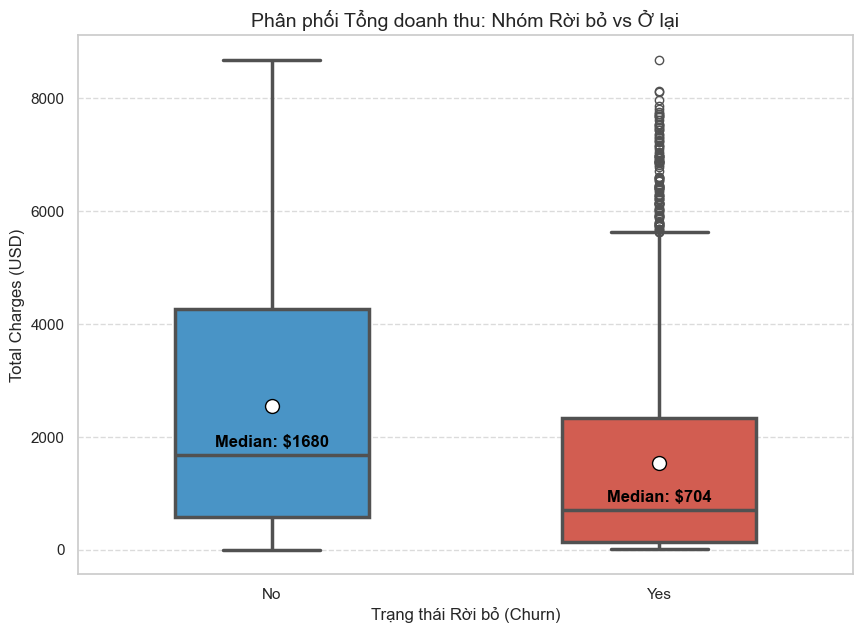

In [43]:
# Biến TotalCharges với Churn
plt.figure(figsize=(10, 7))

# Vẽ Boxplot
ax = sns.boxplot(x='Churn', y='TotalCharges', data=df, palette=['#3498db', '#e74c3c'],
                 width=0.5, linewidth=2.5, showmeans=True,
                 meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"10"})

# Tính toán và hiển thị giá trị Trung vị (Median) ngay trên biểu đồ
medians = df.groupby(['Churn'])['TotalCharges'].median().values
nobs = df['Churn'].value_counts().values
nobs = [str(x) for x in nobs.tolist()]
nobs = ["n: " + i for i in nobs]

# Vòng lặp để viết chữ số lên biểu đồ
pos = range(len(nobs))
for tick, label in zip(pos, ax.get_xticklabels()):
    ax.text(pos[tick], medians[tick] + 150, f'Median: ${medians[tick]:.0f}',
            horizontalalignment='center', size='medium', color='black', weight='semibold')

plt.title('Phân phối Tổng doanh thu: Nhóm Rời bỏ vs Ở lại', fontsize=14)
plt.ylabel('Total Charges (USD)', fontsize=12)
plt.xlabel('Trạng thái Rời bỏ (Churn)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.show()

- Nhóm Ở lại (No): Trung vị là 1680 USD
- Nhóm Rời bỏ (Yes): Trung vị chỉ là 704 USD
- Giá trị trung bình của một khách hàng trung thành cao gấp 2.4 lần so với một khách hàng rời bỏ. Điều này cho thấy khách hàng rời bỏ thường ra đi quá sớm, chưa kịp mang lại nhiều doanh thu cho công ty

### Nhóm biến định tính (Categorical)

#### Biến Contract, InternetService, PaymentMethod với Churn

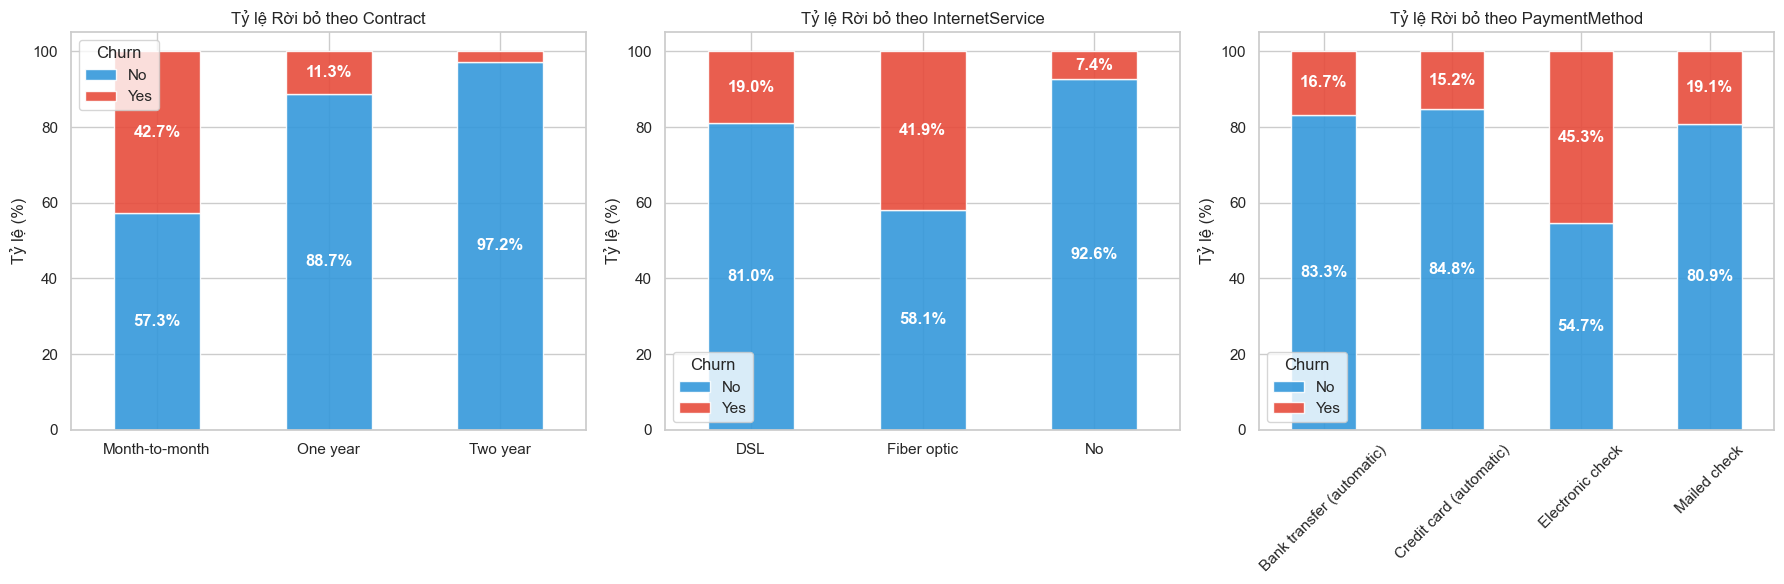

In [44]:
# Biến Contract, InternetService, PaymentMethod với Churn
def plot_churn_rate(df, col, ax):
    # Tạo bảng chéo tính %
    temp = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

    # Vẽ biểu đồ chồng (Stacked Bar)
    temp.plot(kind='bar', stacked=True, ax=ax, color=['#3498db', '#e74c3c'], alpha=0.9, rot=0)

    # Trang trí
    ax.set_title(f'Tỷ lệ Rời bỏ theo {col}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Tỷ lệ (%)')

    # Hiển thị số % lên biểu đồ
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_xy()
        if height > 5: # Chỉ hiện số nếu cột đủ cao
            ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                    ha='center', va='center', color='white', fontweight='bold')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_churn_rate(df, 'Contract', axes[0])
plot_churn_rate(df, 'InternetService', axes[1])
plot_churn_rate(df, 'PaymentMethod', axes[2])
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

***Loại Hợp đồng (Contract):***
- Month-to-month: Tỷ lệ rời bỏ lên tới 42.7%. Tức là cứ 10 người dùng gói tháng thì gần một nửa sẽ rời đi. Đây là con số cực kỳ báo động
- Two year: Tỷ lệ rời bỏ chỉ còn vỏn vẹn 2.8%
Loại hợp đồng chính là yếu tố dự báo mạnh. Nếu khách hàng chịu ký 2 năm, khả năng cao họ sẽ không rời bỏ
- **Chiến lược**: Mọi chiến lược marketing phải xoay quanh việc kéo khách hàng ký dài hạn. Ví dụ: Chấp nhận lỗ giai đoạn đầu hoặc tặng modem xịn nếu khách cam kết 1 năm

***Dịch vụ Internet (Internet Service):***
- Fiber optic (Cáp quang): Tỷ lệ rời bỏ là 41.9%. Đây là vấn đề nghiêm trọng nhất về mặt sản phẩm
- DSL: Tỷ lệ rời bỏ là 19.0%
- No Internet: Tỷ lệ rời bỏ cực thấp 7.4%
- **Vấn đề**: Fiber Optic là dịch vụ cao cấp, đắt tiền nhất, nhưng khách hàng lại bỏ đi nhiều nhất. Chất lượng Cáp quang không tương xứng với giá tiền, hoặc dịch vụ chăm sóc khách hàng cho nhóm này quá tệ, hoặc đối thủ cạnh tranh đang đánh rất mạnh vào phân khúc này
- **Giải pháp**: Cần rà soát lại ngay lập tức hạ tầng kỹ thuật và giá cước của gói Fiber Optic

***Phương thức thanh toán (Payment Method):***
- Electronic check: Tỷ lệ rời bỏ cao kỷ lục 45.3% (thậm chí còn cao hơn cả nhóm dùng Cáp quang hay Hợp đồng tháng)
- Automatic (Credit card / Bank transfer): Tỷ lệ rời bỏ thấp và ổn định (khoảng 15-16%)
- **Insight**: Electronic check yêu cầu khách hàng phải thao tác thủ công mỗi tháng. Mỗi lần thao tác là một lần họ nhận ra mình đang tốn tiền, và một lần cân nhắc "liệu gói dịch vụ này có cần thiết?"

#### Biến gender, SeniorCitizen, Partner, Dependents

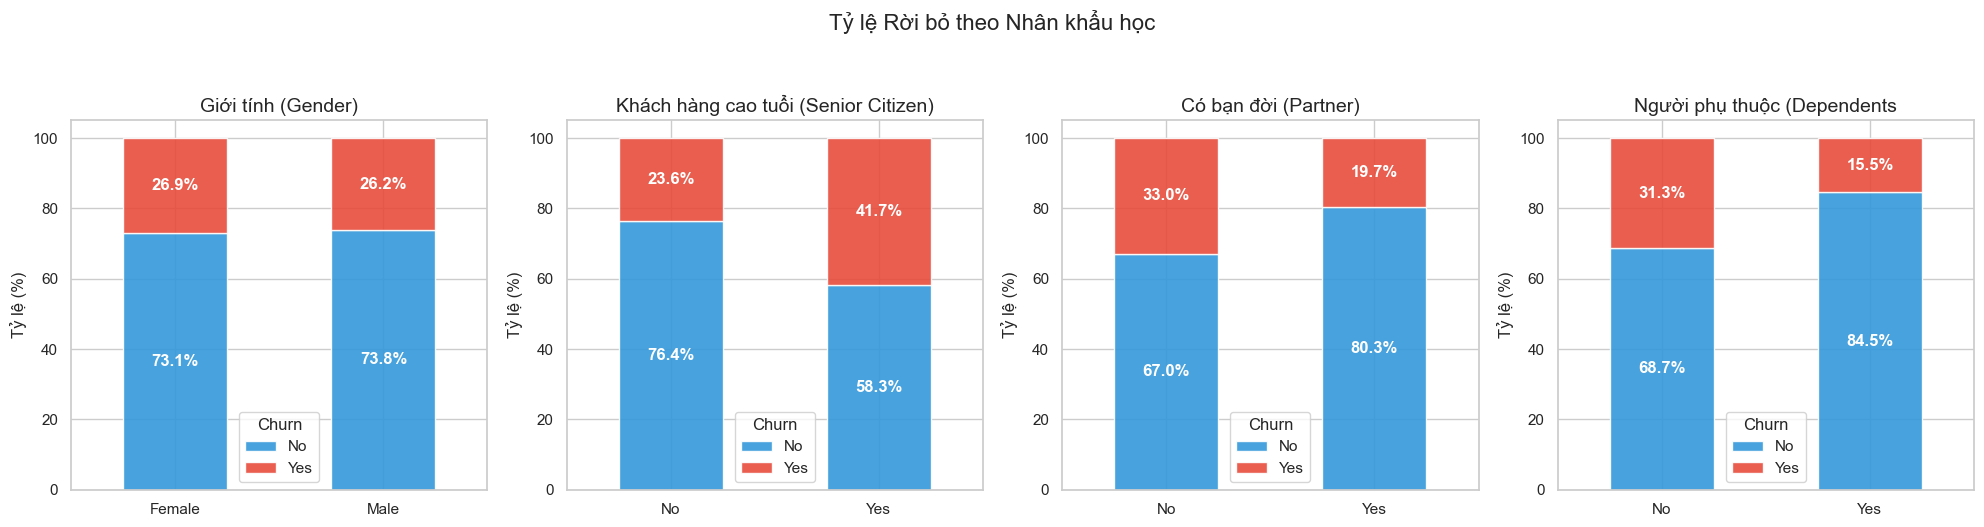

In [45]:
# Tỷ lệ rời bỏ theo nhân khẩu học
# Biến gender, SeniorCitizen, Partner, Dependents với Churn
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Danh sách các biến nhân khẩu học
demographics = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
titles = ['Giới tính (Gender)', 'Khách hàng cao tuổi (Senior Citizen)', 'Có bạn đời (Partner)', 'Người phụ thuộc (Dependents']

for i, col in enumerate(demographics):
    plot_churn_rate(df, col, axes[i])
    axes[i].set_title(titles[i], fontsize=14)

plt.suptitle('Tỷ lệ Rời bỏ theo Nhân khẩu học', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

***Giới tính (Gender):***
- Tỷ lệ rời bỏ giữa Nữ (Female) là 26.9% và Nam (Male) là 26.2%. Sự chênh lệch là không đáng kể (chưa đến 0.7%)
- Giới tính không phải là yếu tố quyết định. Việc khách hàng là nam hay nữ không ảnh hưởng đến việc họ có ghét nhà mạng hay không.

***Khách hàng cao tuổi (Senior Citizen)***
- Người trẻ (No): Rời bỏ 23.6%
- Người cao tuổi (Yes): Rời bỏ lên tới 41.7%
- **Insight**: Nó bác bỏ giả thuyết "người già thì trung thành". Trong bối cảnh viễn thông công nghệ cao, người cao tuổi có thể gặp khó khăn về kỹ thuật, hoặc họ cảm thấy bị tính phí quá cao cho những dịch vụ họ không dùng hết. Họ rời bỏ vì thấy không phù hợp hoặc gặp rắc rối.

***Có bạn đời (Partner) và Người phụ thuộc (Dependents)***
- Partner: Người độc thân (No) rời bỏ 33%, trong khi người có bạn đời (Yes) chỉ rời bỏ 19.7%
- Dependents: Người không có người phụ thuộc (No) rời bỏ 31.3%, trong khi người có con cái/cha mẹ (Yes) chỉ rời bỏ 15.5%
- **Insight**: Nhóm Dependents = Yes là nhóm an toàn nhất trong tất cả các biến nhân khẩu học. Khi một dịch vụ phục vụ cho cả gia đình (con cái học online, bố mẹ xem phim), việc cắt hợp đồng sẽ ảnh hưởng đến nhiều người, gây ra sự phiền toái lớn. Do đó, họ chấp nhận gắn bó lâu dài.

#### Biến PhoneService, MultipleLines, PaperlessBilling với Churn

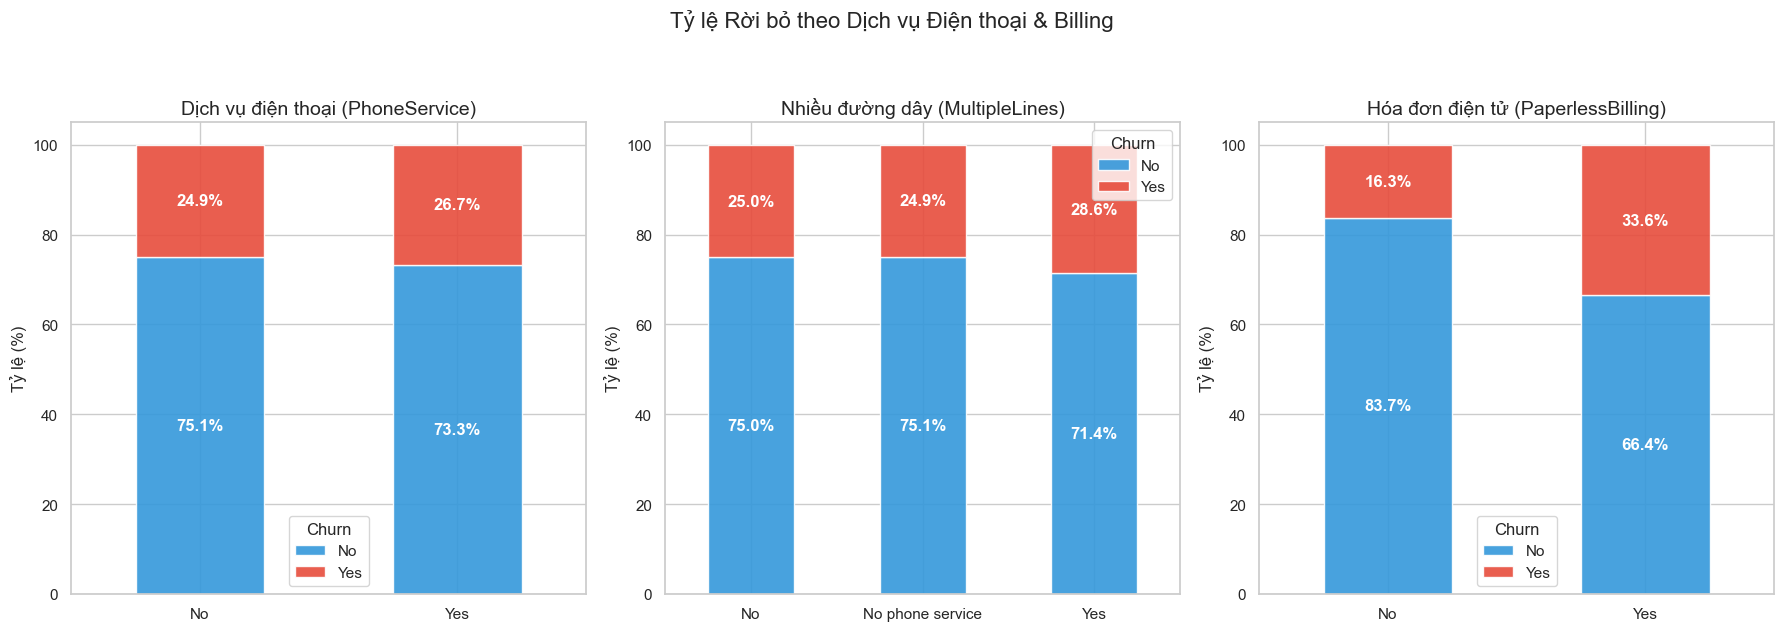

In [46]:
# Biến PhoneService, MultipleLines, PaperlessBilling với Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

others = ['PhoneService', 'MultipleLines', 'PaperlessBilling']
titles_others = ['Dịch vụ điện thoại (PhoneService)', 'Nhiều đường dây (MultipleLines)', 'Hóa đơn điện tử (PaperlessBilling)']

for i, col in enumerate(others):
    plot_churn_rate(df, col, axes[i])
    axes[i].set_title(titles_others[i], fontsize=14)

plt.suptitle('Tỷ lệ Rời bỏ theo Dịch vụ Điện thoại & Billing', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

***Dịch vụ điện thoại (PhoneService):***
- Tỷ lệ rời bỏ của nhóm không sử dụng dịch vụ "No" (24.9%)
- Tỷ lệ rời bỏ của nhóm sử dụng dịch vụ "Yes" (26.7%), chênh lệch không quá 2% so với "No"
- **Insight**: Việc khách hàng có sử dụng điện thoại bàn hay không hầu như không ảnh hưởng đến quyết định rời bỏ của họ

***Nhiều đường dây (MultipleLines):***
- Nhóm sử dụng nhiều đường dây (Yes) có tỷ lệ rời bỏ là 28.6%
- Nhóm dùng 1 đường dây (No) có tỷ lệ rời bỏ: 25%
- **Insight**: Dùng nhiều đường dây đồng nghĩa với cước phí cao hơn, khách hàng càng khắt khe và dễ rời bỏ nếu dịch vụ không như ý. Tuy nhiên, mức độ ảnh hưởng này không quá nghiêm trọng

***Hóa đơn điện tử (PaperlessBilling):***
- Nhóm nhận hóa đơn giấy (No): Tỷ lệ rời bỏ thấp, chỉ 16.3%
- Nhóm hóa đơn điện tử (Yes): Tỷ lệ rời bỏ vọt lên 33.6% (Gấp đôi)
- **Nghịch lí**: Thường ta nghĩ công nghệ cao thì tốt hơn. Những người chọn PaperlessBilling thường là người rành công nghệ, hay dùng Internet nên việc so sánh giá và click chuột để chuyển sang nhà mạng khác đối với họ rất dễ dàng

#### Biến OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies với Churn

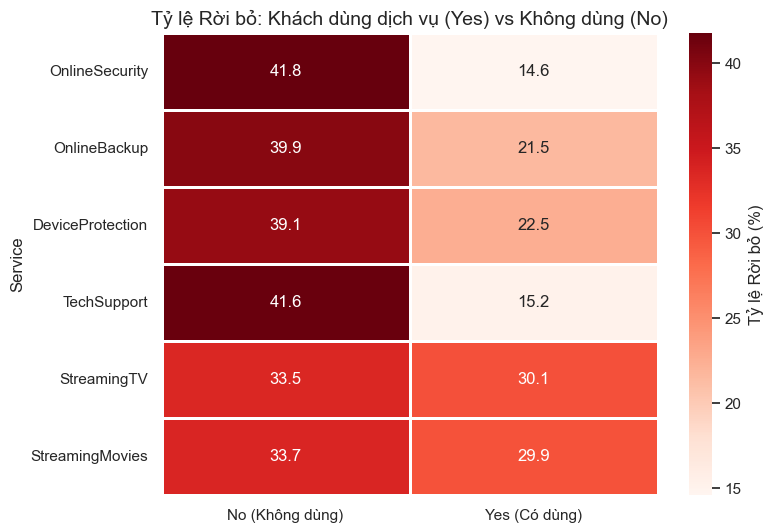

In [47]:
# Tỷ lệ rời bỏ theo biến dịch vụ
# Biến OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies với Churn
# Chọn các cột dịch vụ
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

# Tính tỷ lệ Churn cho từng nhóm (Yes/No/No internet) của mỗi dịch vụ
churn_rates = []
for col in services:
    # Tính % Churn khi giá trị là 'No' (Không dùng dịch vụ)
    rate_no = df[df[col] == 'No']['Churn'].apply(lambda x: 1 if x=='Yes' else 0).mean() * 100
    # Tính % Churn khi giá trị là 'Yes' (Có dùng dịch vụ)
    rate_yes = df[df[col] == 'Yes']['Churn'].apply(lambda x: 1 if x=='Yes' else 0).mean() * 100
    churn_rates.append([col, rate_no, rate_yes])

# Tạo DataFrame cho heatmap
churn_services = pd.DataFrame(churn_rates, columns=['Service', 'No (Không dùng)', 'Yes (Có dùng)'])
churn_services = churn_services.set_index('Service')

# Vẽ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(churn_services, annot=True, fmt=".1f", cmap='Reds', linewidths=1, cbar_kws={'label': 'Tỷ lệ Rời bỏ (%)'})
plt.title('Tỷ lệ Rời bỏ: Khách dùng dịch vụ (Yes) vs Không dùng (No)', fontsize=14)
plt.show()

***OnlineSecurity và TechSupport:***
- TechSupport: Nếu khách hàng không dùng, tỷ lệ rời bỏ là 41.6%. Nhưng nếu họ có dùng, tỷ lệ này rớt xuống chỉ còn 15.2%. (Giảm gần 3 lần)
- OnlineSecurity: Tương tự, giảm từ 41.8% xuống 14.6%
- **Insight**: Đây không chỉ là dịch vụ, đây là niềm tin. Khi khách hàng cảm thấy an toàn và được hỗ trợ kỹ thuật tận tình, họ cực kỳ khó rời đi

***OnlineBackup và DeviceProtection***
- OnlineBackup: Nếu khác hàng không dùng, tỷ lệ rời bỏ là 39.9%. Nếu họ dùng, tỷ lệ này rớt xuống còn 21.5%
- Tương tự với DeviceProtection: giảm từ 39.1 xuống 22.5%
- **Insight**: Việc sao lưu dữ liệu (Backup) và bảo hiểm thiết bị (DeviceProtection) tạo ra rào cản chuyển đổi, khiến khách hàng lười sang nhà mạng khác

***StreamingTV & StreamingMovies***
- StreamingTV: 33.5% (No) vs 30.1% (Yes)
- StreamingMovies: 33.7% (No) và 29.9 (Yes)
- Sự chênh lệch tỷ lệ rời bỏ giữa nhóm "No" và nhóm "Yes" là rất thấp (chỉ khoảng 3-4%).
- **Ý nghĩa**: Việc khách hàng có đăng ký gói xem phim/TV hay không hầu như không giúp ích nhiều cho việc giữ chân họ. Thậm chí, tỷ lệ rời bỏ 30% của nhóm có dùng Streaming vẫn là rất cao so với nhóm dùng TechSupport (15.2%).
- **Lí do**: Dịch vụ giải trí thường đi kèm với cước phí cao và yêu cầu tốc độ mạng cao (Fiber optic). Nếu mạng lag hoặc giá đắt, họ sẵn sàng cắt hợp đồng để chuyển sang xem trên nền tảng khác (như Netflix hoặc Youtube)

### Ma trận tương quan (Correlation Matrix)

#### Nhóm các biến định lượng (Numerical)

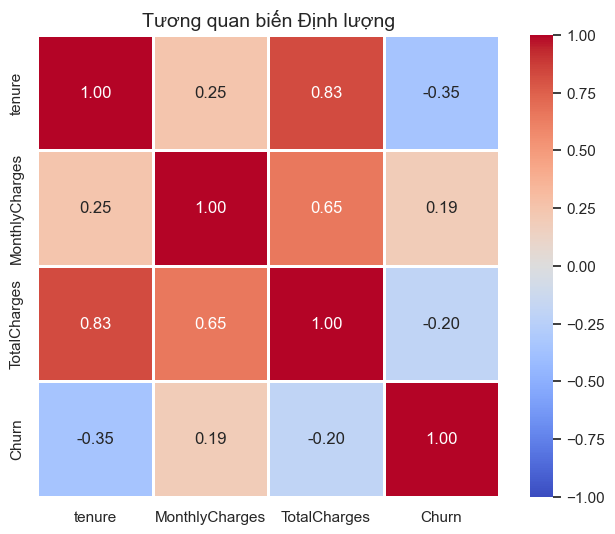

In [48]:
# Ma trận tương quan các biến định lượng (numerical)
# Tạo df copy
df_quant = df.copy()

# Mã hóa biến Churn (Yes=1, No=0) để xem tương quan với các số khác
df_quant['Churn'] = df_quant['Churn'].map({'Yes': 1, 'No': 0})

# Chỉ chọn các cột số thực sự
quant_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
df_quant = df_quant[quant_cols]

# Vẽ Heatmap
plt.figure(figsize=(8, 6))
corr_quant = df_quant.corr()

sns.heatmap(corr_quant,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmax=1, vmin=-1,
            linewidths=1,
            square=True)

plt.title('Tương quan biến Định lượng', fontsize=14)
plt.show()

***Tenure (Thâm niên)***
- Hệ số: -0.35 (Tương quan nghịch mức độ trung bình-khá).
- Ý nghĩa: Đây là hệ số âm lớn nhất trong biểu đồ. Số âm  nghĩa là: Tenure càng tăng thì khả năng rời bỏ càng giảm
- Điều này xác nhận hoàn toàn biểu đồ cột trước đó (Tenure với Churn) Khách hàng lâu năm rất ít khi rời bỏ.
- **Kết luận**: tenure chắc chắn là một trong những feature quan trọng nhất cho mô hình dự báo.

***MonthlyCharges (Cước phí tháng)***
- Hệ số: +0.19 (Tương quan thuận mức độ nhẹ)
- Ý nghĩa: Con số dương nghĩa là cước phí càng cao, khả năng rời bỏ càng tăng
- Tuy nhiên, mức 0.19 không phải là quá mạnh (so với 0.35 của tenure)

***TotalCharges (Tổng doanh thu)***
- Hệ số: -0.20 (Tương quan nghịch)
- **Nghịch lí**: Tại sao trả phí tháng cao thì dễ rời bỏ, mà trả tổng tiền nhiều lại ít rời bỏ
- Vì TotalCharges tương đương với MonthlyCharges x Tenure mà những người có TotalCharges cao thường là những người gắn bó lâu (Tenure cao) và Tenure có tác động chống lại Churn rất mạnh, nó kéo luôn cả TotalCharges đi theo hướng âm

#### Nhóm các biến định tính (Categorical)

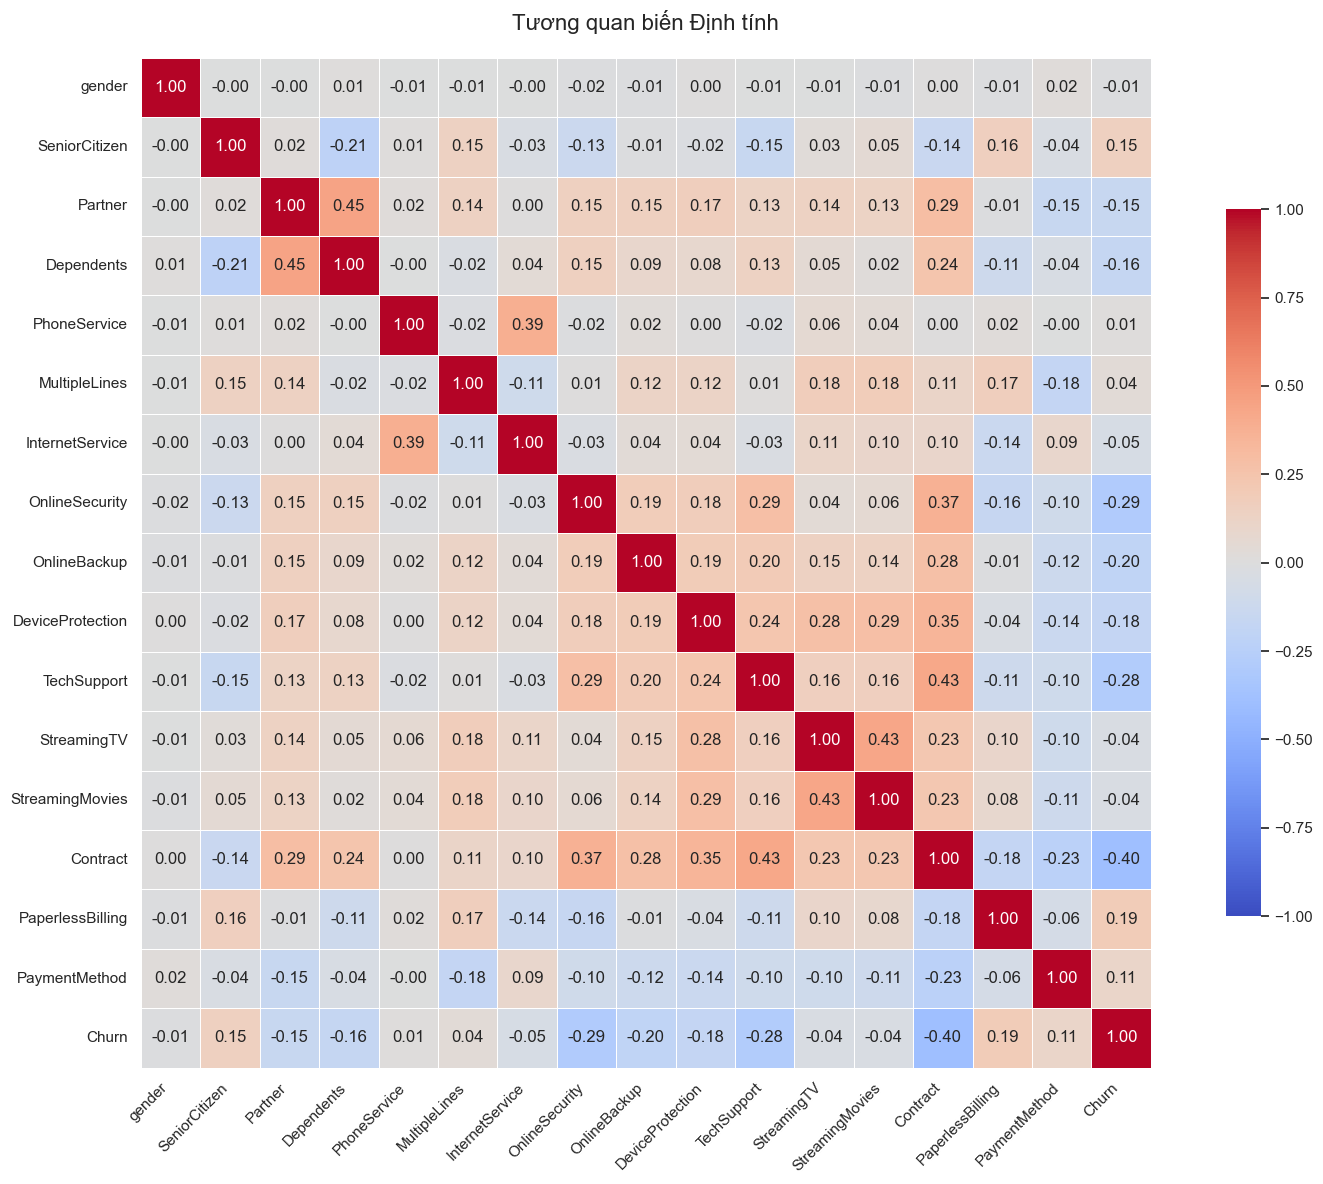

In [49]:
# Tạo df copy
df_qual = df.copy()

# Loại bỏ các cột số và ID, chỉ giữ lại các cột category và Churn
drop_cols = ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
# Chỉ drop những cột nào thực sự tồn tại để tránh lỗi
df_qual = df_qual.drop(columns=[c for c in drop_cols if c in df_qual.columns])

# Mã hóa toàn bộ các cột còn lại (Label Encoding)
for col in df_qual.columns:
    df_qual[col] = df_qual[col].astype('category').cat.codes

# Vẽ Heatmap
plt.figure(figsize=(16, 12))
corr_qual = df_qual.corr()

sns.heatmap(corr_qual,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            vmax=1, vmin=-1,
            center=0,
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": .7})

plt.title('Tương quan biến Định tính', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Contract (Hợp đồng)**:
- Hệ số: -0.4. Đây là biến có tương quan mạnh nhất với Churn trong tất cả các biến định tính
- Loại hợp đồng càng cao (từ Month-to-month -> One year -> Two year), thì tỷ lệ Churn càng thấp


- **OnlineSecurity** (-0.17) và **TechSupport** (-0.16). Hệ số âm xác nhận lại phân tích trước đó: Càng sử dụng các dịch vụ này, khách hàng càng ít rời bỏ. Đây là những biến quan trọng thứ 2 sau Contract
- **Gender** (Giới tính): -0.01, **PhoneService** (Dịch vụ điện thoại): 0.01, **MultipleLines**: 0.04, những biến này gần như không có mối quan hệ tuyến tính nào với việc rời bỏ
- Biến **InternetService** có hệ số tương quan rất thấp (-0.05). Trước đó ở biểu đồ cột, nhóm "Fiber Optic" rời bỏ ầm ầm (41%), còn nhóm "No Internet" thì ở lại. Đây là do label encoding, máy hiểu: DSL=0, Fiber=1, No=2. Lúc này mối quan hệ ở đây không phải là tuyến tính, Fiber (1) có Churn cao nhất, nhưng nằm giữa 0 và 2 làm cho hệ số tương quan Pearson triệt tiêu lẫn nhau. Tương tự với **PaymentMedthod**

## Feature Engineering

In [50]:
# Tạo nhóm thâm niên (Tenure Grouping)
# Giúp mô hình bắt được quy luật theo giai đoạn thay vì từng tháng lẻ tẻ
bins = [0, 12, 24, 36, 48, 60, 80]
labels = ['0-12 Month', '12-24 Month', '24-36 Month', '36-48 Month', '48-60 Month', '> 60 Month']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

In [51]:
# Tạo biến Tổng số dịch vụ sử dụng (TotalServices)
# Suy nghĩ theo logic: Khách dùng càng nhiều dịch vụ trong hệ sinh thái thì càng khó rời bỏ
services_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
# Đếm số lượng dịch vụ khách hàng đang dùng (chỉ đếm nếu giá trị không phải 'No' hoặc 'No internet service')
df['TotalServices'] = df[services_cols].apply(lambda x: x.isin(['Yes', 'Fiber optic', 'DSL']).sum(), axis=1)

In [52]:
# Tạo biến giá cước trung bình trên mỗi dịch vụ AvgPricePerService
df['AvgPricePerService'] = df['MonthlyCharges'] / df['TotalServices'].replace(0, 1)

In [53]:
# Tạo biến Phân loại nhóm gia đình (FamilyCluster)
# 0: Độc thân, 1: Có Partner hoặc Con cái, 2: Có cả hai (Gia đình lớn)
df['FamilyCluster'] = df['Partner'].map({'Yes': 1, 'No': 0}) + df['Dependents'].map({'Yes': 1, 'No': 0})

In [54]:
# Tạo biến cờ cho thanh toán tự động (AutoPayment)
# Bank transfer và Credit card là tự động, còn lại là thủ công
payment_mapping = {
    'Bank transfer (automatic)': 1,
    'Credit card (automatic)': 1,
    'Mailed check': 0,
    'Electronic check': 0
}
df['AutoPayment'] = df['PaymentMethod'].map(payment_mapping)

In [55]:
# Tạo biến Gói giải trí (StreamPackage)
# Khách hàng dùng cả 2 dịch vụ giải trí thường là khách hàng cá nhân có nhu cầu cao
# 1: Dùng cả StreamingTV VÀ StreamingMovies, 0: Không dùng hoặc chỉ dùng 1
df['StreamPackage'] = ((df['StreamingTV'] == 'Yes') & (df['StreamingMovies'] == 'Yes')).astype(int)

In [56]:
# Tạo biến Gói an toàn & hỗ trợ (SupportPackage)
# Đếm số lượng dịch vụ kỹ thuật: Security, Backup, Protection, TechSupport
support_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
df['SupportPackage'] = df[support_cols].apply(lambda x: x.isin(['Yes']).sum(), axis=1)

In [57]:
# Tạo biến Nhóm nguy cơ cao (HighRiskProfile)
# Combo: Hợp đồng tháng + Electronic check dễ gây Churn nhất
df['HighRiskProfile'] = ((df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check')).astype(int)

## Tìm kiếm insight

#### Insight 1 - Phân tích nguyên nhân dẫn đến sự sụt giảm tỷ lệ rời bỏ theo thâm niên khách hàng

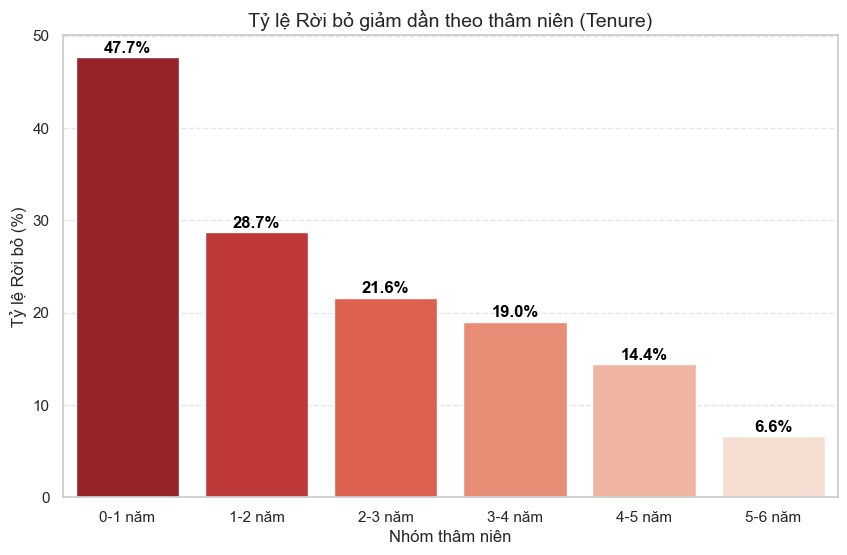

In [58]:
# Biến Tenure vs Churn
# Tạo bản sao tạm thời để xử lý dữ liệu vẽ
df_viz = df.copy()

# Xử lý phân nhóm
bins = [0, 12, 24, 36, 48, 60, 72]
labels = ['0-1 năm', '1-2 năm', '2-3 năm', '3-4 năm', '4-5 năm', '5-6 năm']

df_viz['TenureGroup'] = pd.cut(df_viz['tenure'], bins=bins, labels=labels)

# Tính toán tỷ lệ Churn
churn_by_tenure = df_viz.groupby('TenureGroup', observed=False)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='TenureGroup', y='Churn', data=churn_by_tenure, palette='Reds_r') # Reds_r để màu nhạt dần

plt.title('Tỷ lệ Rời bỏ giảm dần theo thâm niên (Tenure)', fontsize=14)
plt.ylabel('Tỷ lệ Rời bỏ (%)', fontsize=12)
plt.xlabel('Nhóm thâm niên', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm số % lên đầu cột
for index, row in churn_by_tenure.iterrows():
    if not pd.isna(row.Churn):
        plt.text(index, row.Churn + 0.5, f"{row.Churn:.1f}%", color='black', ha="center", fontweight='bold')

plt.show()

<Figure size 1200x700 with 0 Axes>

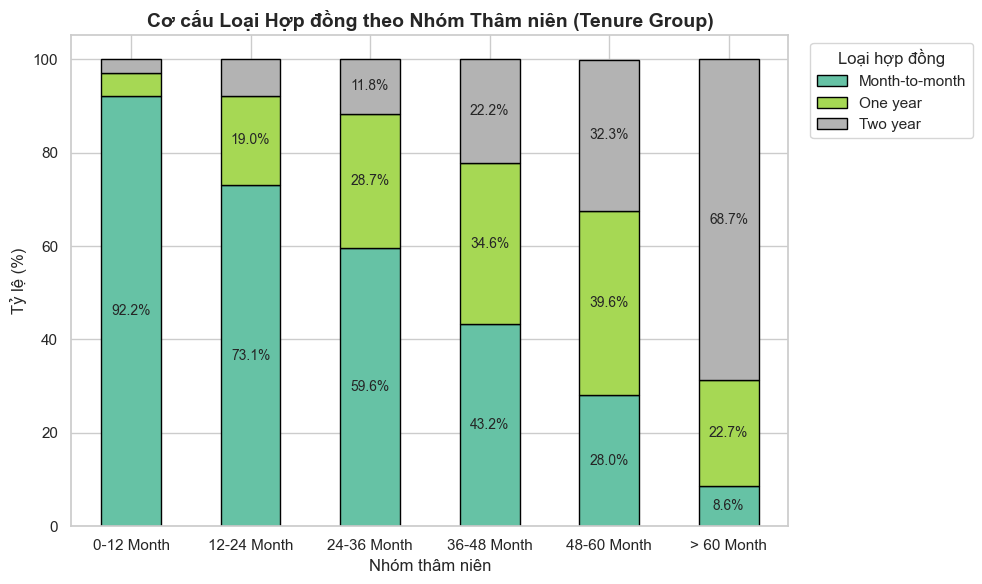

In [59]:
# Bảng tỷ lệ Contract theo từng TenureGroup
contract_tenure_pct = pd.crosstab(
    df['TenureGroup'],
    df['Contract'],
    normalize='index'
) * 100

contract_tenure_pct = contract_tenure_pct.round(1)
contract_tenure_pct


plt.figure(figsize=(12, 7))

contract_tenure_pct.plot(
    kind='bar',
    stacked=True,
    colormap='Set2',
    edgecolor='black'
)

plt.title('Cơ cấu Loại Hợp đồng theo Nhóm Thâm niên (Tenure Group)',
          fontsize=14, fontweight='bold')
plt.xlabel('Nhóm thâm niên')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(rotation=0)
plt.legend(title='Loại hợp đồng', bbox_to_anchor=(1.02, 1), loc='upper left')

# Hiển thị % trên từng phần (chỉ hiện nếu đủ lớn)
for i, group in enumerate(contract_tenure_pct.index):
    y_offset = 0
    for value in contract_tenure_pct.loc[group]:
        if value >= 8:
            plt.text(
                i,
                y_offset + value / 2,
                f'{value:.1f}%',
                ha='center',
                va='center',
                fontsize=10
            )
        y_offset += value

plt.tight_layout()
plt.show()


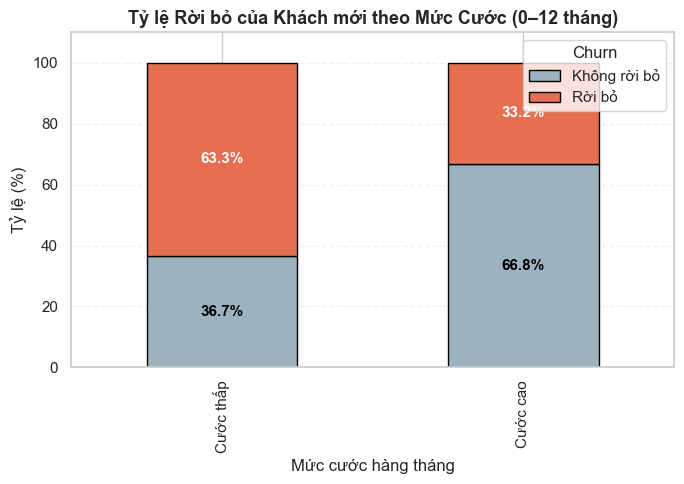

In [60]:
# Lọc dữ liệu khách hàng mới (0-12 tháng)
new_customers = df[df['TenureGroup'] == '0-12 Month'].copy()

# Chia nhóm cước phí
threshold = new_customers['MonthlyCharges'].median()

new_customers['ChargeGroup'] = new_customers['MonthlyCharges'].apply(
    lambda x: 'High Charge' if x > threshold else 'Low Charge'
)

# Bước 3: Tính tỷ lệ rời bỏ theo nhóm cước (Crosstab & Normalize)
highcharge_churn = pd.crosstab(new_customers['ChargeGroup'], new_customers['Churn'])
# Chuẩn hóa để ra phần trăm (tổng hàng = 100%)
highcharge_churn_pct = highcharge_churn.div(highcharge_churn.sum(1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#9DB2BF', '#E76F51']  # Không rời bỏ / Rời bỏ

highcharge_churn_pct.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor='black'
)

# Tiêu đề gọn, dễ đọc
ax.set_title(
    'Tỷ lệ Rời bỏ của Khách mới theo Mức Cước (0–12 tháng)',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Mức cước hàng tháng')
ax.set_ylabel('Tỷ lệ (%)')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Cước thấp', 'Cước cao'], fontsize=11)

# Legend gọn gàng
ax.legend(
    title='Churn',
    labels=['Không rời bỏ', 'Rời bỏ'],
    loc='upper right'
)

# Gắn % — chỉ hiện phần đủ lớn
for i, group in enumerate(highcharge_churn_pct.index):
    y_offset = 0
    for j, value in enumerate(highcharge_churn_pct.loc[group]):
        if value >= 12:  # ngưỡng để tránh rối
            ax.text(
                i,
                y_offset + value / 2,
                f'{value:.1f}%',
                ha='center',
                va='center',
                fontsize=11,
                color='white' if j == 1 else 'black',
                fontweight='bold'
            )
        y_offset += value

ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


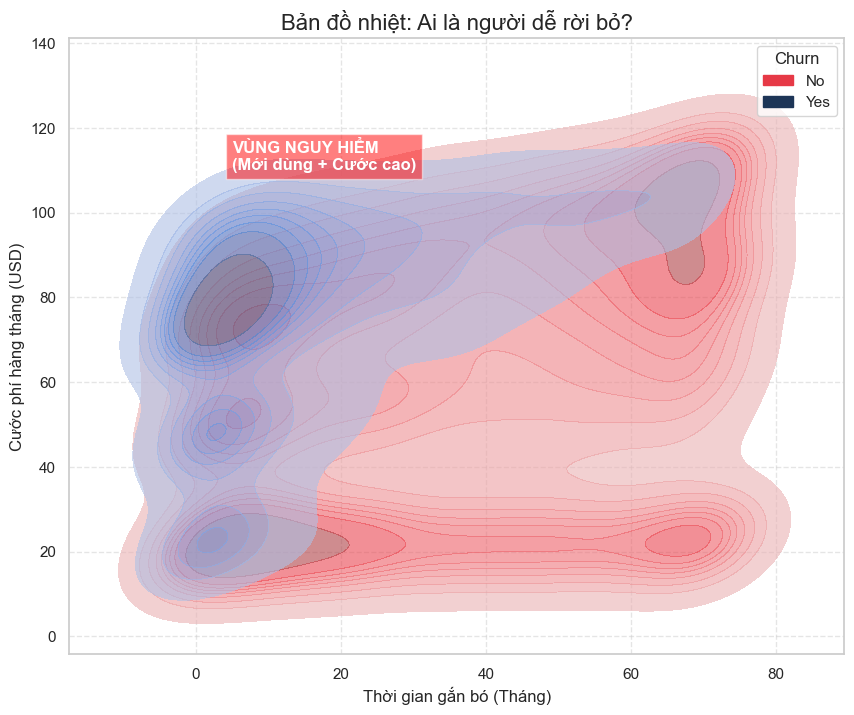

In [61]:
# KDE Plot (Biểu đồ đường mức)
plt.figure(figsize=(10, 8))

sns.kdeplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn',
            fill=True, alpha=0.6, palette=['#E63946', '#1D3557'])

plt.title('Bản đồ nhiệt: Ai là người dễ rời bỏ?', fontsize=16)
plt.xlabel('Thời gian gắn bó (Tháng)')
plt.ylabel('Cước phí hàng tháng (USD)')
plt.grid(True, linestyle='--', alpha=0.5)

# Vùng màu xanh đậm là vùng "Nguy hiểm"
plt.text(5, 110, 'VÙNG NGUY HIỂM\n(Mới dùng + Cước cao)',
         fontsize=12, color='white', weight='bold',
         bbox=dict(facecolor='red', alpha=0.5))

plt.show()

***Insight rút ra***:
- Tỷ lệ rời bỏ đạt đỉnh ở nhóm khách hàng có thâm niên dưới 12 tháng, chủ yếu do sự phổ biến của các hợp đồng ngắn hạn với mức độ cam kết thấp.
- Khi khách hàng vượt qua mốc một năm và chuyển sang các hình thức hợp đồng dài hạn, tỷ lệ rời bỏ giảm mạnh, cho thấy vai trò then chốt của ràng buộc hợp đồng trong việc ổn định hành vi sử dụng dịch vụ
- **Biện pháp**: Việc khuyến khích khách hàng mới chuyển sang các gói hợp đồng một năm ngay trong giai đoạn đầu được xem là giải pháp hiệu quả nhằm giảm thiểu rủi ro rời bỏ

#### Insight 2 - Phân tích tỷ lệ rời bỏ của dịch vụ Fiber Optic và các yếu tố liên quan

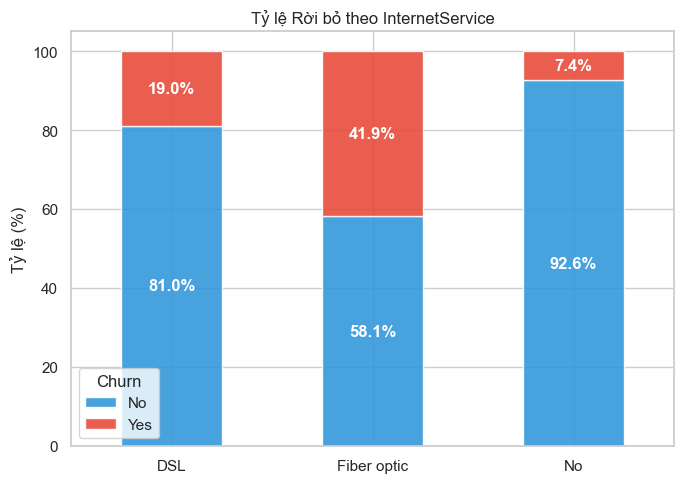

In [62]:
# Biến InternetService với Churn
fig, ax = plt.subplots(figsize=(7, 5))

plot_churn_rate(df, 'InternetService', ax)

plt.tight_layout()
plt.show()

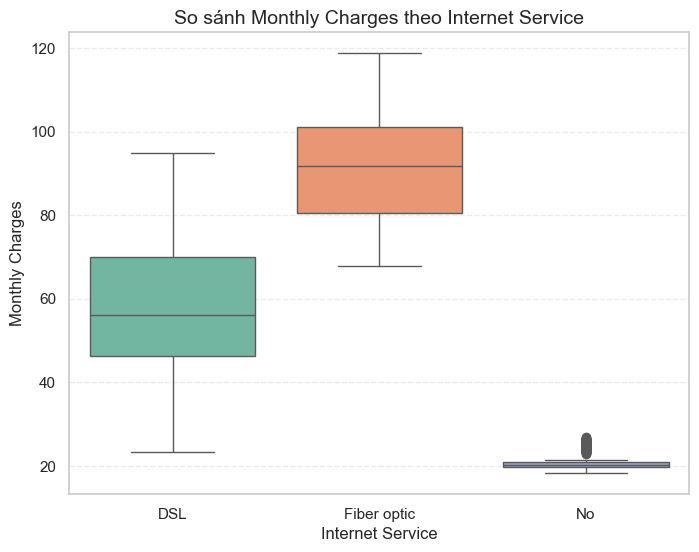

In [63]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='InternetService',
    y='MonthlyCharges',
    palette='Set2'
)

plt.title('So sánh Monthly Charges theo Internet Service', fontsize=14)
plt.xlabel('Internet Service')
plt.ylabel('Monthly Charges')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


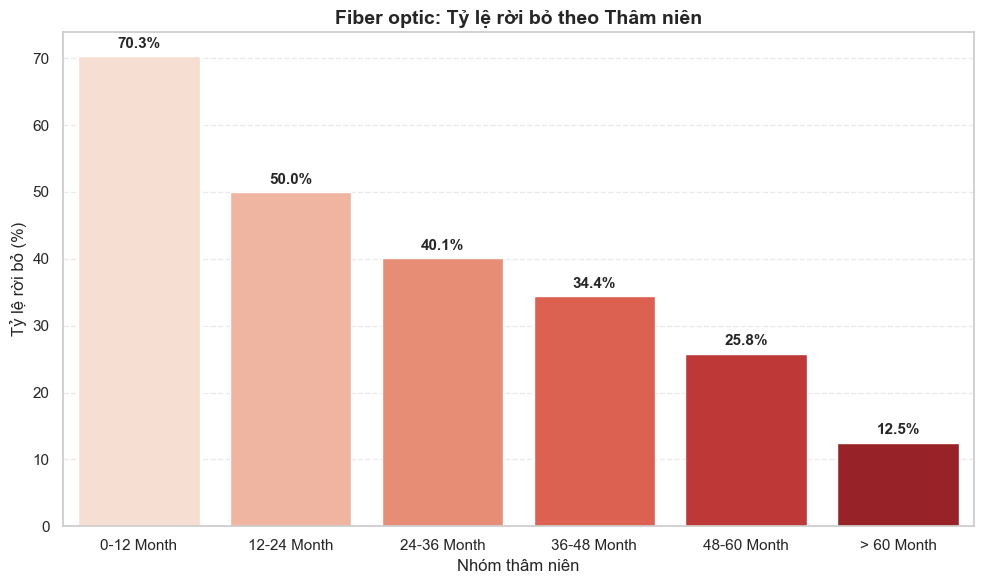

In [64]:
# Tính tỷ lệ churn (%) theo TenureGroup cho Fiber optic
fiber_tenure_churn = (
    df[df['InternetService'] == 'Fiber optic']
    .groupby('TenureGroup')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
)

# Vẽ biểu đồ
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=fiber_tenure_churn,
    x='TenureGroup',
    y='Churn',
    palette='Reds'
)

# Trang trí
ax.set_title(
    'Fiber optic: Tỷ lệ rời bỏ theo Thâm niên',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Nhóm thâm niên')
ax.set_ylabel('Tỷ lệ rời bỏ (%)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Gắn % lên đầu cột
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.text(
            p.get_x() + p.get_width()/2,
            height + 0.8,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()


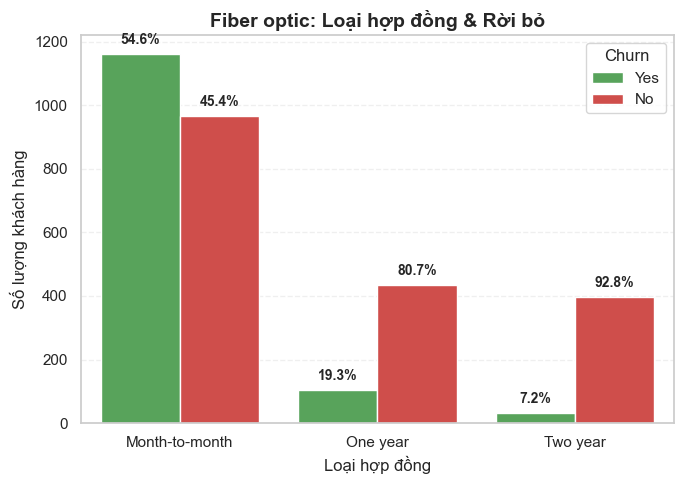

In [65]:
df_fiber = df[df['InternetService'] == 'Fiber optic']

plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=df_fiber,
    x='Contract',
    hue='Churn',
    palette=['#4CAF50', '#E53935']
)

# Tiêu đề & nhãn
ax.set_title('Fiber optic: Loại hợp đồng & Rời bỏ',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Loại hợp đồng')
ax.set_ylabel('Số lượng khách hàng')

total_per_contract = (
    df_fiber
    .groupby('Contract')
    .size()
    .to_dict()
)

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue

    # Xác định contract của cột
    contract = p.get_x() + p.get_width() / 2
    contract_label = ax.get_xticklabels()[int(round(contract))].get_text()

    percent = height / total_per_contract[contract_label] * 100

    if percent >= 5:  # tránh rối
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + max(total_per_contract.values()) * 0.01,
            f'{percent:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# Trang trí
ax.legend(title='Churn')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


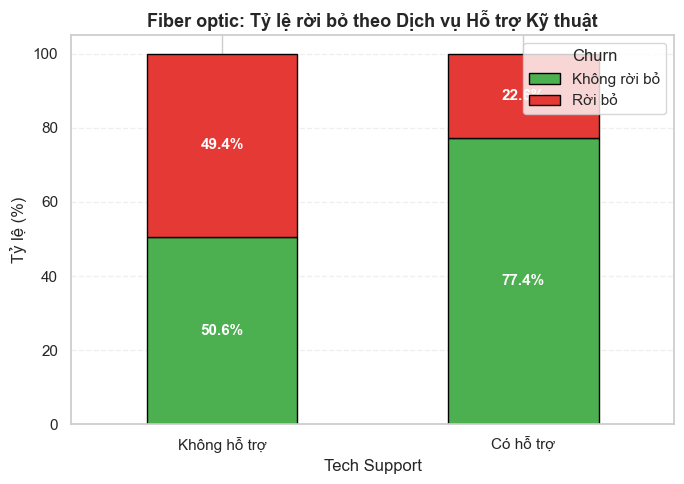

In [66]:
support_fiber = pd.crosstab(
    df_fiber['TechSupport'],
    df_fiber['Churn'],
    normalize='index'
) * 100

support_fiber = support_fiber.round(1)

ax = support_fiber.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5),
    color=['#4CAF50', '#E53935'],
    edgecolor='black'
)

ax.set_title(
    'Fiber optic: Tỷ lệ rời bỏ theo Dịch vụ Hỗ trợ Kỹ thuật',
    fontsize=13,
    fontweight='bold'
)
ax.set_xlabel('Tech Support')
ax.set_ylabel('Tỷ lệ (%)')
ax.set_xticklabels(['Không hỗ trợ', 'Có hỗ trợ'], rotation=0)

ax.legend(title='Churn', labels=['Không rời bỏ', 'Rời bỏ'], loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.3)

# Gắn % lên cột
for i, group in enumerate(support_fiber.index):
    y_offset = 0
    for value in support_fiber.loc[group]:
        if value >= 8:
            ax.text(
                i,
                y_offset + value/2,
                f'{value:.1f}%',
                ha='center',
                va='center',
                fontsize=11,
                fontweight='bold',
                color='white'
            )
        y_offset += value

plt.tight_layout()
plt.show()

***Insight rút ra:***
- Mặc dù mang lại doanh thu cao, dịch vụ cáp quang (Fiber Optic) lại đi kèm tỷ lệ rời bỏ lớn
- Đặc biệt ở những khách hàng chỉ sử dụng số lượng dịch vụ hạn chế.
- Phân tích cho thấy việc thiếu các dịch vụ hỗ trợ kỹ thuật khiến mức giá cao không được cảm nhận là tương xứng, trong khi những khách hàng được tích hợp vào một hệ sinh thái dịch vụ đa dạng có xu hướng duy trì hợp đồng ổn định hơn
- **Biện pháp**: có thể khẳng định rằng bài toán giữ chân khách hàng Fiber Optic không nằm ở việc điều chỉnh giá, mà ở việc gia tăng mức độ gắn kết thông qua hỗ trợ kỹ thuật và hệ sinh thái dịch vụ. Thay vì cung cấp Fiber Optic như một dịch vụ đơn lẻ, doanh nghiệp cần định hướng phát triển các gói dịch vụ tích hợp, trong đó Tech Support đóng vai trò nền tảng và các dịch vụ giá trị gia tăng giúp nâng tổng số dịch vụ sử dụng lên một ngưỡng đủ cao. Cách tiếp cận này góp phần giảm đáng kể tỷ lệ rời bỏ và bảo vệ nguồn doanh thu từ nhóm khách hàng có giá trị cao

#### Insight 3 - Phân tích tỷ lệ rời bỏ của phương thức thanh toán Electonic Check và các yếu tố liên quan

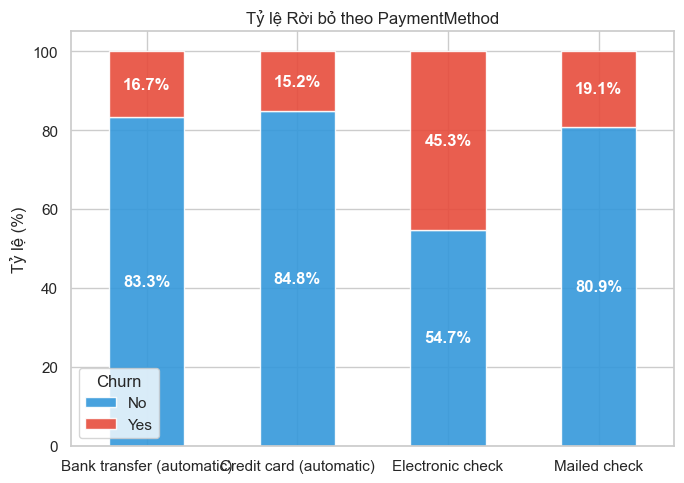

In [67]:
# Biến PaymentMethod với Churn
fig, ax = plt.subplots(figsize=(7, 5))

plot_churn_rate(df, 'PaymentMethod', ax)

plt.tight_layout()
plt.show()

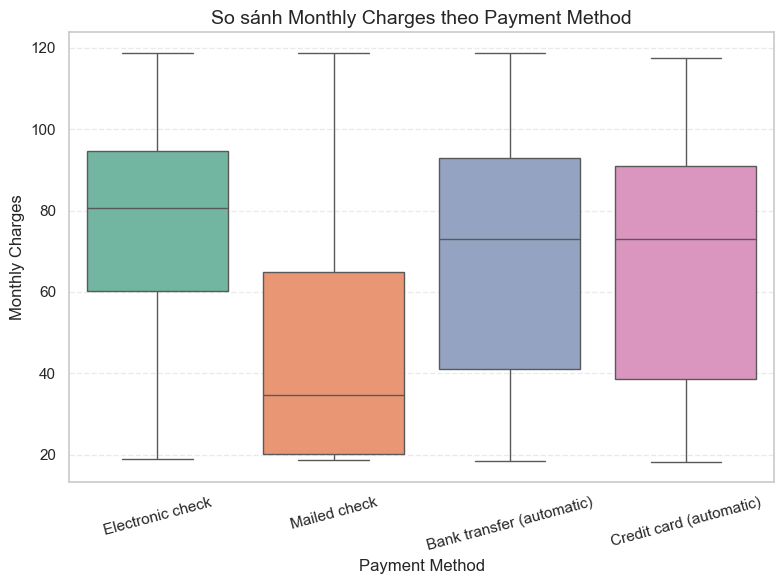

In [68]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='PaymentMethod',
    y='MonthlyCharges',
    palette='Set2'
)

plt.title('So sánh Monthly Charges theo Payment Method', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Monthly Charges')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


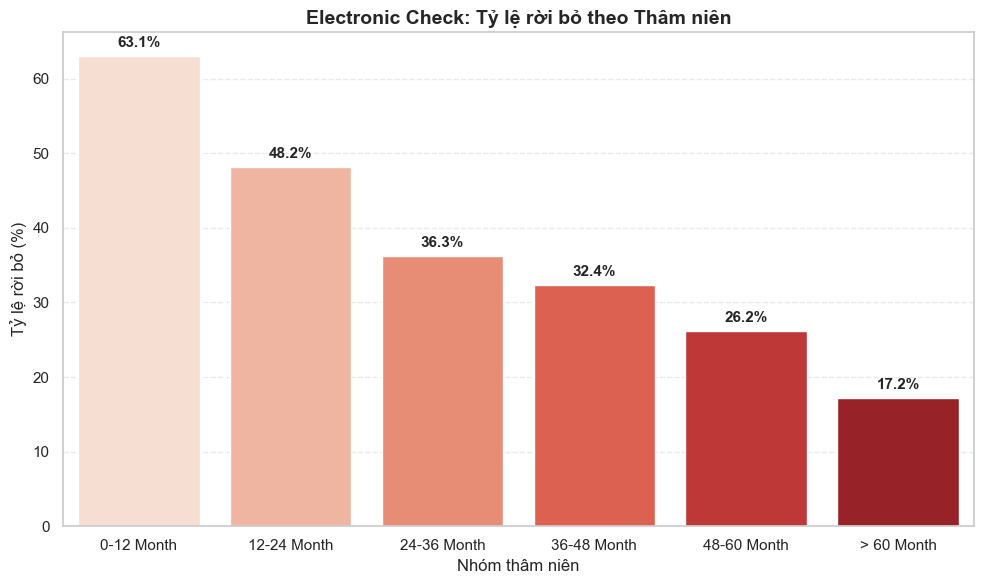

In [69]:
# Tính churn rate (%) theo TenureGroup cho Electronic Check
ec_tenure_churn = (
    df[df['PaymentMethod'] == 'Electronic check']
    .groupby('TenureGroup')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
)

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=ec_tenure_churn,
    x='TenureGroup',
    y='Churn',
    palette='Reds'
)

ax.set_title(
    'Electronic Check: Tỷ lệ rời bỏ theo Thâm niên',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Nhóm thâm niên')
ax.set_ylabel('Tỷ lệ rời bỏ (%)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Gắn % lên cột
for p in ax.patches:
    height = p.get_height()
    if not pd.isna(height):
        ax.text(
            p.get_x() + p.get_width()/2,
            height + 0.8,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()


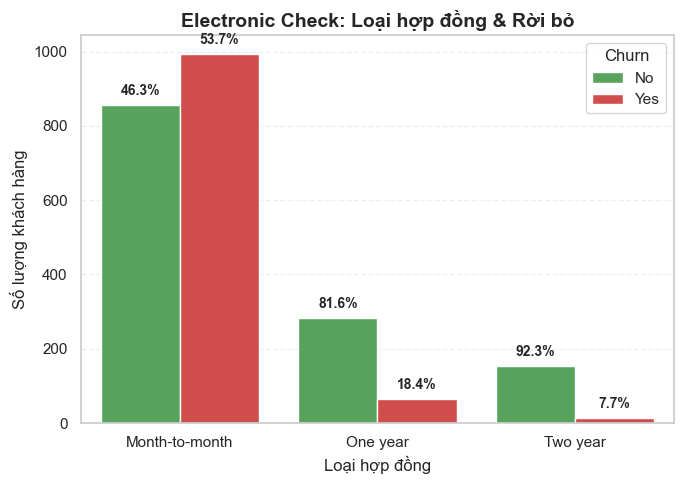

In [70]:
df_ec = df[df['PaymentMethod'] == 'Electronic check']

plt.figure(figsize=(7,5))
ax = sns.countplot(
    data=df_ec,
    x='Contract',
    hue='Churn',
    palette=['#4CAF50', '#E53935']
)

ax.set_title(
    'Electronic Check: Loại hợp đồng & Rời bỏ',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Loại hợp đồng')
ax.set_ylabel('Số lượng khách hàng')

total_per_contract = (
    df_ec.groupby('Contract').size().to_dict()
)

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue

    contract = p.get_x() + p.get_width() / 2
    contract_label = ax.get_xticklabels()[int(round(contract))].get_text()
    percent = height / total_per_contract[contract_label] * 100

    if percent >= 5:
        ax.text(
            p.get_x() + p.get_width()/2,
            height + max(total_per_contract.values()) * 0.01,
            f'{percent:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

ax.legend(title='Churn')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

***Insight rút ra***
- Nhóm khách hàng sử dụng séc điện tử (Electronic Check) là nhóm có hành vi rủi ro cao. Tỷ lệ rời bỏ ở nhóm này lên tới 45.3%, cao gấp 3 lần so với nhóm thanh toán tự động
- Phản ánh sự bất tiện và nỗi đau chi trả khi khách hàng phải thao tác thủ công hàng tháng cho các hóa đơn có giá trị lớn.
- Đặc biệt, khi phương thức này đi kèm với hợp đồng theo tháng(Month-to-month), sự thiếu cam kết bị đẩy lên đỉnh điểm, khiến tỷ lệ hủy dịch vụ trong năm đầu tiên vọt lên mức báo động 63.1%
- **Biện pháp**: Thúc đẩy chuyển đổi sang thanh toán tự động bằng các ưu đãi giảm giá trực tiếp được xem là giải pháp tối ưu để loại bỏ nỗi đau chi trả hàng tháng, đặc biệt khi so sánh với rủi ro đánh mất nhóm khách hàng mang lại doanh thu trung bình rất cao nhưng lại có xu hướng rời bỏ ồ ạt ngay trong năm đầu tiên

#### Insight 4 - Phân tích đặc điểm nhân khẩu học và vai trò của dịch vụ hỗ trợ

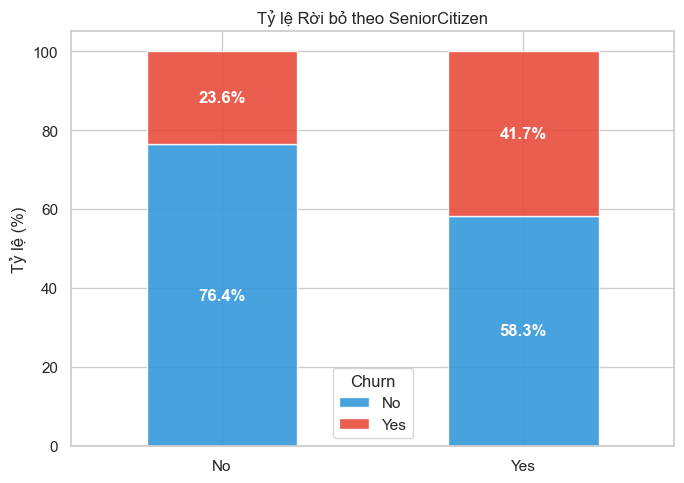

In [71]:
# Biến PaymentMethod với Churn
fig, ax = plt.subplots(figsize=(7, 5))

plot_churn_rate(df, 'SeniorCitizen', ax)

plt.tight_layout()
plt.show()

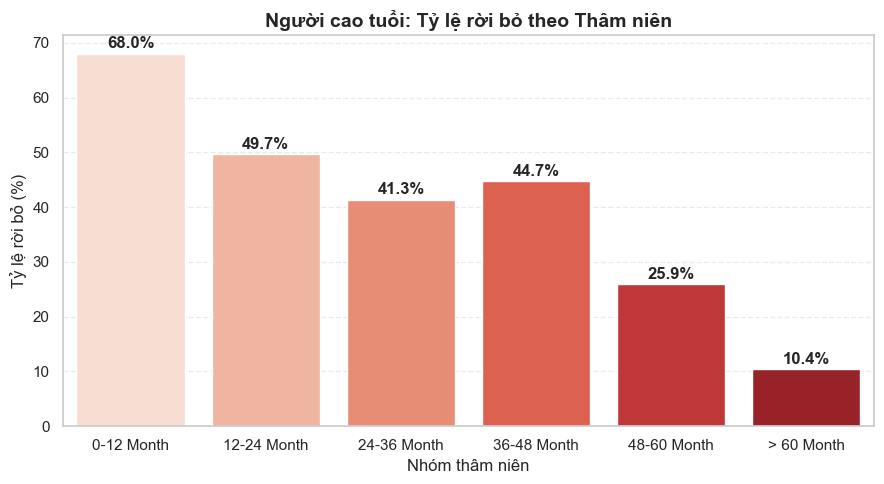

In [72]:
senior_tenure = (
    df[df['SeniorCitizen']=='Yes']
    .groupby('TenureGroup')['Churn']
    .apply(lambda x: (x=='Yes').mean()*100)
    .reset_index()
)

plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=senior_tenure,
    x='TenureGroup',
    y='Churn',
    palette='Reds'
)

ax.set_title(
    'Người cao tuổi: Tỷ lệ rời bỏ theo Thâm niên',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Nhóm thâm niên')
ax.set_ylabel('Tỷ lệ rời bỏ (%)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

for p in ax.patches:
    ax.text(
        p.get_x()+p.get_width()/2,
        p.get_height()+1,
        f'{p.get_height():.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

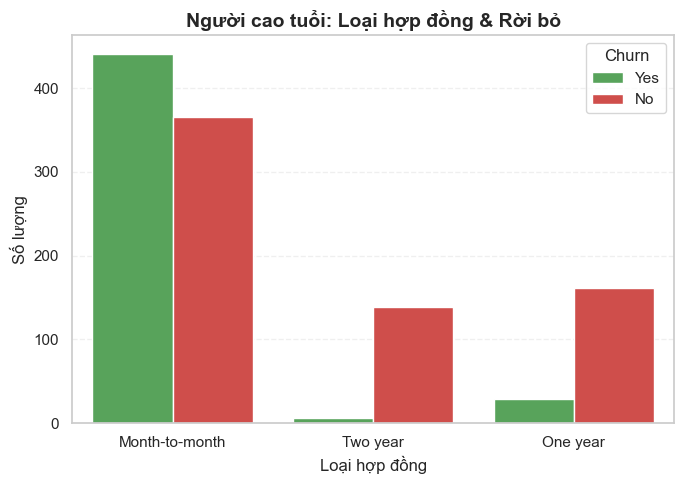

In [73]:
df_senior = df[df['SeniorCitizen']=='Yes']

plt.figure(figsize=(7,5))
ax = sns.countplot(
    data=df_senior,
    x='Contract',
    hue='Churn',
    palette=['#4CAF50','#E53935']
)

ax.set_title(
    'Người cao tuổi: Loại hợp đồng & Rời bỏ',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('Loại hợp đồng')
ax.set_ylabel('Số lượng')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Churn')

plt.tight_layout()
plt.show()

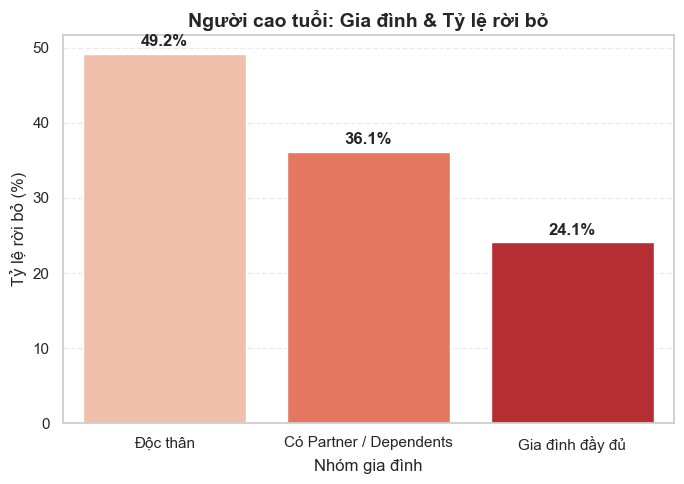

In [74]:
df_senior = df[df['SeniorCitizen'] == 'Yes']

family_churn = (
    df_senior
    .groupby('FamilyCluster')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
)

plt.figure(figsize=(7,5))
ax = sns.barplot(
    data=family_churn,
    x='FamilyCluster',
    y='Churn',
    palette='Reds'
)

ax.set_title(
    'Người cao tuổi: Gia đình & Tỷ lệ rời bỏ',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Nhóm gia đình')
ax.set_ylabel('Tỷ lệ rời bỏ (%)')
ax.set_xticklabels([
    'Độc thân',
    'Có Partner / Dependents',
    'Gia đình đầy đủ'
])
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Gắn %
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/2,
        p.get_height() + 1,
        f'{p.get_height():.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


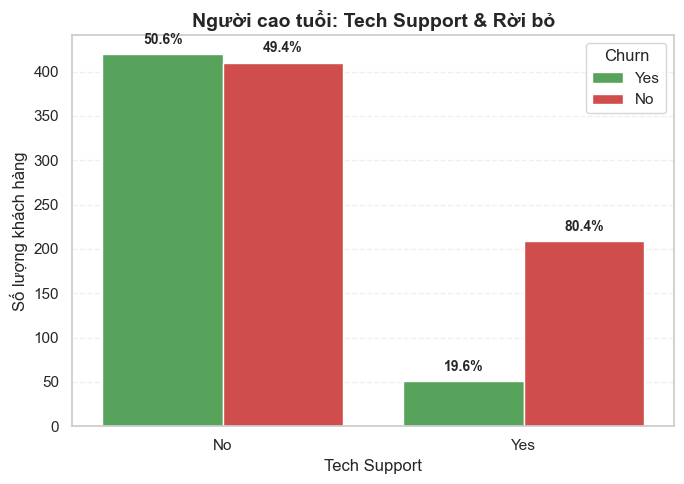

In [75]:
# Lọc đúng đối tượng insight
df_senior_ts = df[
    (df['SeniorCitizen'] == 'Yes') &
    (df['InternetService'] != 'No')
]

plt.figure(figsize=(7,5))
ax = sns.countplot(
    data=df_senior_ts,
    x='TechSupport',
    hue='Churn',
    palette=['#4CAF50', '#E53935']
)

ax.set_title(
    'Người cao tuổi: Tech Support & Rời bỏ',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Tech Support')
ax.set_ylabel('Số lượng khách hàng')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Churn')

total_per_support = (
    df_senior_ts
    .groupby('TechSupport')
    .size()
    .to_dict()
)

for p in ax.patches:
    height = p.get_height()
    if height == 0:
        continue

    support = p.get_x() + p.get_width() / 2
    support_label = ax.get_xticklabels()[int(round(support))].get_text()
    percent = height / total_per_support[support_label] * 100

    if percent >= 5:
        ax.text(
            p.get_x() + p.get_width()/2,
            height + max(total_per_support.values()) * 0.01,
            f'{percent:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()


***Insight rút ra***
- Nhóm khách hàng cao tuổi là nhóm nhạy cảm nhất với tỷ lệ rời bỏ lên tới 41.7% (gấp gần 2 lần mức trung bình)
- Con số này phản ánh rào cản lớn trong việc tiếp cận công nghệ, đặc biệt nghiêm trọng ở nhóm khách hàng sống độc thân (tỉ lệ rời bỏ khoảng 49%).
- Đáng chú ý, việc thiếu đi dịch vụ hỗ trợ kỹ thuật (TechSupport) là nguyên nhân chính đẩy sự không hài lòng lên đỉnh điểm, khiến hơn 50% nhóm này quyết định chấm dứt hợp đồng
- **Biện pháp**: tích hợp gói Tech Support miễn phí hoặc áp dụng chính sách ưu đãi cho khách hàng cao tuổi được xem là giải pháp hiệu quả về mặt chi phí, đặc biệt khi so sánh với các khoản đầu tư cần thiết để thu hút khách hàng mới nhằm bù đắp tỷ lệ rời bỏ

#### Insight từ việc tạo biến mới

**TotalServices** - Biến Tổng số dịch vụ mà khách sử dụng

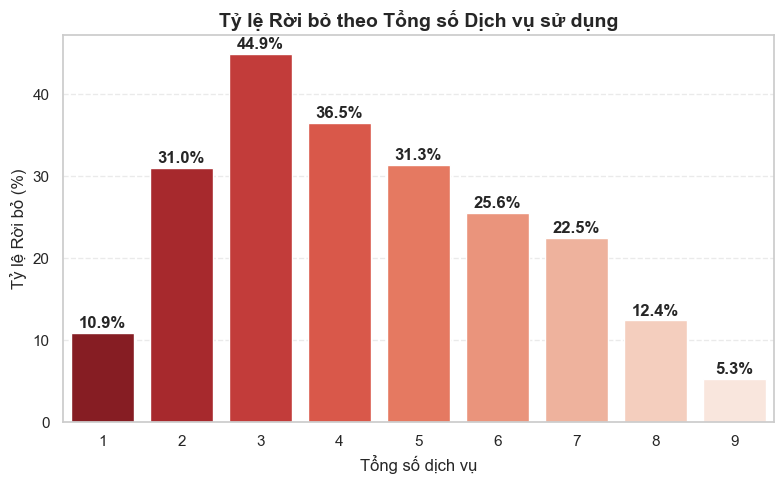

In [76]:
churn_by_services = (
    df.groupby('TotalServices')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=churn_by_services,
    x='TotalServices',
    y='Churn',
    palette='Reds_r'
)

plt.title('Tỷ lệ Rời bỏ theo Tổng số Dịch vụ sử dụng', fontsize=14, fontweight='bold')
plt.xlabel('Tổng số dịch vụ')
plt.ylabel('Tỷ lệ Rời bỏ (%)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Gắn %
for i, row in churn_by_services.iterrows():
    plt.text(i, row.Churn + 0.6, f"{row.Churn:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


- Nếu chỉ sử dụng 1 dịch vụ: Tỷ lệ rời bỏ thấp (10.9%). Đây là nhóm khách hàng có nhu cầu cơ bản, ít đòi hỏi, và hóa đơn thấp nên họ không có lý do gì để phàn nàn hay rời đi
- Sử dụng từ 2 - 3 dịch vụ: Tỷ lệ rời bỏ tăng vọt từ 31% đạt đỉnh ở mức 44.9% (khi dùng 3 dịch vụ). Đây là ngưỡng thử nghiệm. Họ dùng đủ nhiều để thấy tốn tiền, nhưng chưa đủ nhiều để cảm thấy gắn bó không thể tách rời
- Giai đoạn cam kết (4 - 9): Tỷ lệ rời bỏ giảm dần đều, xuống mức cực thấp 5.3% (khi dùng trọn bộ 9 dịch vụ). Khi khách hàng đã lún sâu vào hệ sinh thái, chi phí chuyển đổi trở nên quá lớn. Họ lười thay đổi và trở thành khách hàng trung thành

**Biến AvgPricePerService** -  Trung bình giá mỗi gói dịch vụ

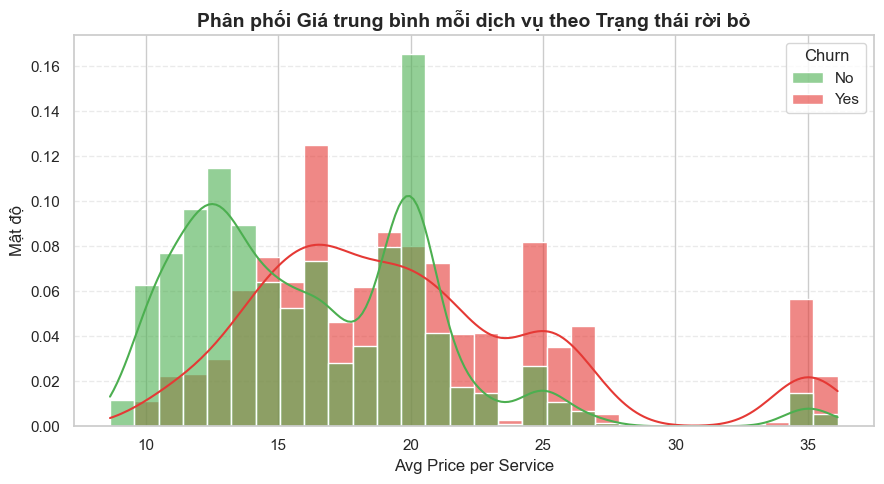

In [77]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x='AvgPricePerService',
    hue='Churn',
    bins=30,
    kde=True,
    stat='density',
    common_norm=False,
    palette=['#4CAF50', '#E53935'],
    alpha=0.6
)

plt.title(
    'Phân phối Giá trung bình mỗi dịch vụ theo Trạng thái rời bỏ',
    fontsize=14, fontweight='bold'
)
plt.xlabel('Avg Price per Service')
plt.ylabel('Mật độ')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

- Ở mức giá 20 USD: cột màu xanh (No) cao vút lên ở mốc 20 USD. Đây là mức giá chấp nhận được của đại đa số khách hàng, khách hàng cảm thấy đáng tiền và rất ít khi rời bỏ. Đường màu xanh ở khu vực này lấn át hoàn toàn đường màu đỏ
- Ở mức giá 25 - 35 USD: các cột màu đỏ (Yes) bắt đầu cao hơn. Khi giá trung bình cho một dịch vụ bị đẩy lên quá cao, khách hàng bắt đầu cảm thấy không đáng tiền
- Trước đó, ta thấy MonthlyCharges cao thì dễ rời bỏ. Nhưng biểu đồ đó không giải thích được tại sao có những người trả 100 vẫn ở lại. Khách hàng không rời bỏ vì hóa đơn cao, họ rời bỏ vì "giá trị nhận được trên mỗi đồng bỏ ra thấp"

**Biến FamilyCluster** - Cấu trúc gia đình

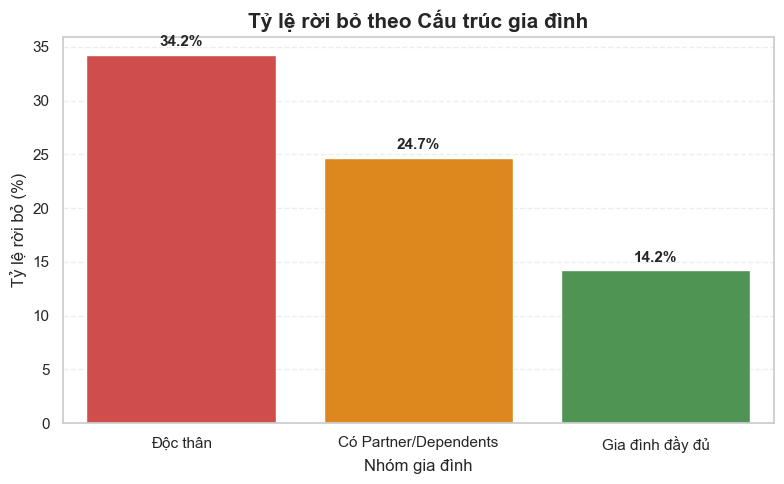

In [78]:
plt.figure(figsize=(8,5))

familycl_churn = (
    df.groupby('FamilyCluster')['Churn']
    .apply(lambda x: (x=='Yes').mean()*100)
    .reset_index()
)

ax = sns.barplot(
    data=familycl_churn,
    x='FamilyCluster',
    y='Churn',
    palette=['#E53935', '#FB8C00', '#43A047']
)

# Tiêu đề & nhãn
ax.set_title(
    'Tỷ lệ rời bỏ theo Cấu trúc gia đình',
    fontsize=15,
    fontweight='bold'
)
ax.set_xlabel('Nhóm gia đình')
ax.set_ylabel('Tỷ lệ rời bỏ (%)')
ax.set_xticklabels(['Độc thân', 'Có Partner/Dependents', 'Gia đình đầy đủ'])

ax.grid(axis='y', linestyle='--', alpha=0.35)

# Gắn % trên cột
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width()/2,
        p.get_height() + 0.8,
        f'{p.get_height():.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )


plt.tight_layout()
plt.show()

- Độc thân (Không Partner, Không Dependents): Rủi ro cao nhất (34.2%). Đây là nhóm chỉ cần quyết định cho riêng mình, dễ dàng chuyển nhà, thay đổi công việc, hoặc đơn giản là muốn thử một nhà mạng mới xem có rẻ hơn không. Đây là nhóm khách hàng linh hoạt nhưng thiếu sự trung thành tự nhiên
- Có 1 trong 2 (Chỉ có Partner hoặc Dependents) Rủi ro trung bình (24.7%).
- Gia đình đầy đủ (Có cả Partner và Dependents): Rủi ro thấp nhất (14.2%). Khi cả gia đình (vợ chồng, con cái) cùng dùng đường truyền Internet/TV của nhà mạng, chi phí chuyển đổi về mặt tâm lý và vận hành là rất lớn. Do đó, họ có xu hướng cam kết lâu dài

**Biến SupportPackage** - Số lượng gói hỗ trợ kĩ thuật sử dụng

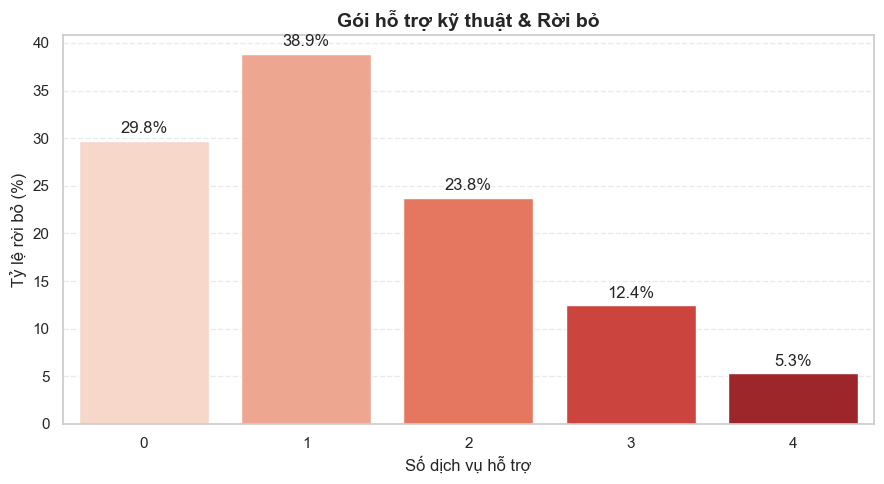

In [79]:
support_churn = (
    df.groupby('SupportPackage')['Churn']
    .apply(lambda x: (x=='Yes').mean()*100)
    .reset_index()
)

plt.figure(figsize=(9,5))
ax = sns.barplot(
    data=support_churn,
    x='SupportPackage',
    y='Churn',
    palette='Reds'
)

ax.set_title('Gói hỗ trợ kỹ thuật & Rời bỏ', fontsize=14, fontweight='bold')
ax.set_xlabel('Số dịch vụ hỗ trợ')
ax.set_ylabel('Tỷ lệ rời bỏ (%)')
ax.grid(axis='y', linestyle='--', alpha=0.4)

for p in ax.patches:
    ax.text(
        p.get_x()+p.get_width()/2,
        p.get_height()+0.8,
        f'{p.get_height():.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

- Càng ít dịch vụ hỗ trợ càng dễ rời bỏ: Cột số 1 tỉ lệ rời bỏ đạt đỉnh cao nhất tại đây (38.9%). Tỷ lệ này thậm chí còn cao hơn nhiều so với nhóm không dùng dịch vụ hỗ trợ nào (29.8%)
- Từ mốc 2 dịch vụ trở đi, tỷ lệ rời bỏ lao dốc không phanh, 2 dịch vụ: 23.8%, 3 dịch vụ: 12.4%, 4 dịch vụ: Chỉ còn 5.3%. Khi khách hàng mua trọn bộ dịch vụ hỗ trợ, việc hủy hợp đồng đồng nghĩa với việc mất đi toàn bộ lớp bảo vệ dữ liệu và thiết bị này. Rào cản tâm lý quá lớn khiến họ trở thành những khách hàng trung thành
- Khách hàng dùng 1 dịch vụ  thường là những người đã phát sinh vấn đề hoặc lo lắng, nhưng giải pháp đơn lẻ không giải quyết triệt để nỗi đau của họ. Nhóm không dùng dịch vụ hỗ trợ gồm những khách hàng nhạy cảm về giá. Họ dễ bị lôi kéo bởi đối thủ có giá rẻ hơn vì không có gì ràng buộc ngoài giá cước cơ bản

**Biến HighRiskProfile** - Đại diện cho nhóm có nguy cơ rời bỏ cao

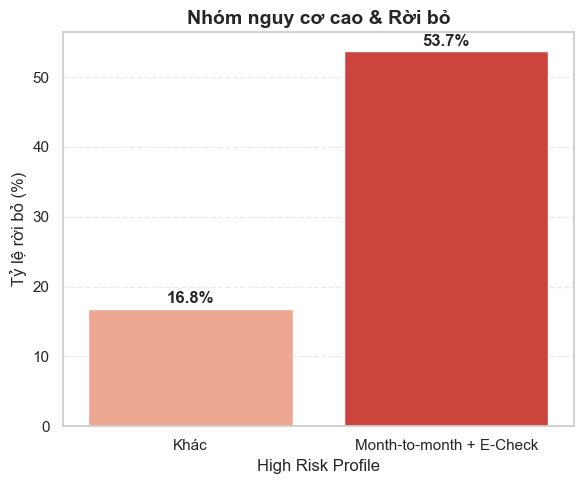

In [80]:
risk_churn = (
    df.groupby('HighRiskProfile')['Churn']
    .apply(lambda x: (x=='Yes').mean()*100)
    .reset_index()
)

plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=risk_churn,
    x='HighRiskProfile',
    y='Churn',
    palette='Reds'
)

ax.set_title('Nhóm nguy cơ cao & Rời bỏ', fontsize=14, fontweight='bold')
ax.set_xlabel('High Risk Profile')
ax.set_ylabel('Tỷ lệ rời bỏ (%)')
ax.set_xticklabels(['Khác', 'Month-to-month + E-Check'])
ax.grid(axis='y', linestyle='--', alpha=0.4)

for p in ax.patches:
    ax.text(
        p.get_x()+p.get_width()/2,
        p.get_height()+0.8,
        f'{p.get_height():.1f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

- Nhóm Rủi ro cao (Month-to-month + E-Check): Tỷ lệ rời bỏ lên tới 53.7%. Cứ 2 người thuộc nhóm này thì có hơn 1 người sẽ rời bỏ. Đây là nhóm khách hàng đáng chú ý nhất đối với doanh thu, lúc này công ty cần có chiến dịch níu kéo nhóm khách hàng này, chỉ cần thay đổi 1 trong 2 yếu tố (hoặc đổi sang hợp đồng năm, hoặc đổi sang thanh toán tự động)
- Nhóm còn lại (Khác): Tỷ lệ rời bỏ chỉ là 16.8%. Nếu loại bỏ nhóm khách hàng rủi ro kia, thực tế là đại đa số khách hàng của doanh nghiệp này khá trung thành. Tỷ lệ 16.8% là mức chấp nhận được trong ngành viễn thông.

**Biến AutoPayment** - Hình thức thanh toán

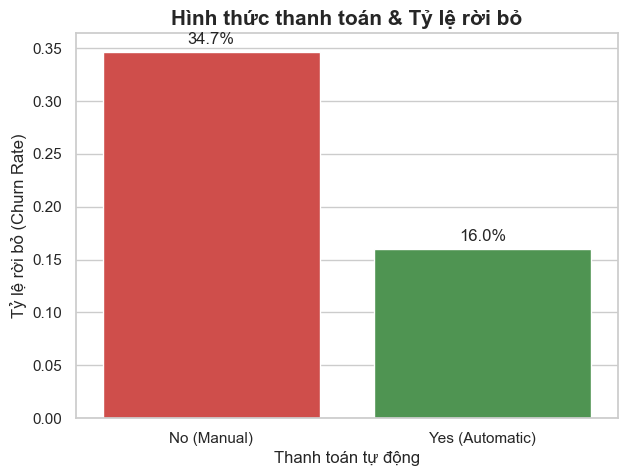

In [81]:
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

auto_churn = df.groupby('AutoPayment')['Churn'].mean().reset_index()

auto_churn['AutoPayment'] = auto_churn['AutoPayment'].map({0: 'No (Manual)', 1: 'Yes (Automatic)'})

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=auto_churn,
    x='AutoPayment',
    y='Churn',
    palette=['#E53935', '#43A047']
)

ax.set_title('Hình thức thanh toán & Tỷ lệ rời bỏ', fontsize=15, fontweight='bold')
ax.set_ylabel('Tỷ lệ rời bỏ (Churn Rate)')
ax.set_xlabel('Thanh toán tự động')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()


- Thanh toán Thủ công (No - Manual): Tỷ lệ rời bỏ lên tới 34.7%
- Thanh toán Tự động (Yes - Automatic): Tỷ lệ rời bỏ chỉ còn 16.0%
- Insight: Khách hàng phải tự tay trả tiền mỗi tháng có xu hướng rời bỏ cao gấp hơn 2 lần so với nhóm để tiền tự trừ trong tài khoản